# 📐 Math & Statistics for AI/ML — Part 2: Deep Dive

**Going deeper: Linear Algebra, Calculus, Optimization, MLE/MAP, Sampling, Variational Inference, and Statistical Testing — the engine room of modern ML.**

---

> **Prerequisites:** [Part 1: Foundations](math_and_stats_for_ml_part1.ipynb) — Probability, Distributions, Information Theory, Loss Functions, Activation Functions, Norms & Regularization.

## 📑 Table of Contents

| # | Topic | Key Concepts |
|---|-------|-------------|
| 1 | **Linear Algebra for ML** | Vectors, Matrices, Eigendecomposition, SVD, PCA |
| 2 | **Matrix Calculus & Gradients** | Jacobians, Hessians, Chain Rule, Backpropagation |
| 3 | **Optimization** | Gradient Descent, SGD, Momentum, Adam, Learning Rate Schedules |
| 4 | **Maximum Likelihood & MAP Estimation** | Deriving losses from first principles, MLE vs MAP |
| 5 | **Sampling Methods** | Monte Carlo, Importance Sampling, MCMC, Reparameterization Trick |
| 6 | **Variational Inference** | ELBO, VAEs, the full derivation |
| 7 | **Hypothesis Testing & Statistical Significance** | p-values, Confidence Intervals, A/B Testing for ML |

---

## 🔧 Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch, Circle, Ellipse
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats, linalg
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Color palette
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63']
print('Setup complete!')

Setup complete!


---
# 1. 🔢 Linear Algebra for ML

Linear algebra is the **backbone** of ML. Every forward pass, every gradient computation, every data transformation is a matrix operation. Understanding these operations deeply separates those who use ML from those who *understand* it.

---

## 1.1 Vectors & Dot Products — The Foundation of Similarity

A vector $\mathbf{x} \in \mathbb{R}^n$ is an ordered list of $n$ numbers. In ML, **everything is a vector** — words, images, gradients, model parameters.

### Dot Product (Inner Product)

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i = \|\mathbf{a}\| \|\mathbf{b}\| \cos\theta$$

The dot product encodes **three** things simultaneously:

| Property | Formula | ML Usage |
|----------|---------|----------|
| **Magnitude** of projection | $\text{proj}_{\mathbf{b}} \mathbf{a} = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{b}\|}$ | Attention scores |
| **Similarity** direction | $\cos\theta = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$ | Cosine similarity |
| **Weighted sum** | $\mathbf{w} \cdot \mathbf{x} + b$ | Linear layer, perceptron |

### Cosine Similarity
$$\text{cos\_sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|_2 \|\mathbf{b}\|_2} \in [-1, 1]$$

> **ML Usage:** Word embeddings (Word2Vec, GloVe), sentence similarity, retrieval systems, contrastive learning (CLIP, SimCLR).

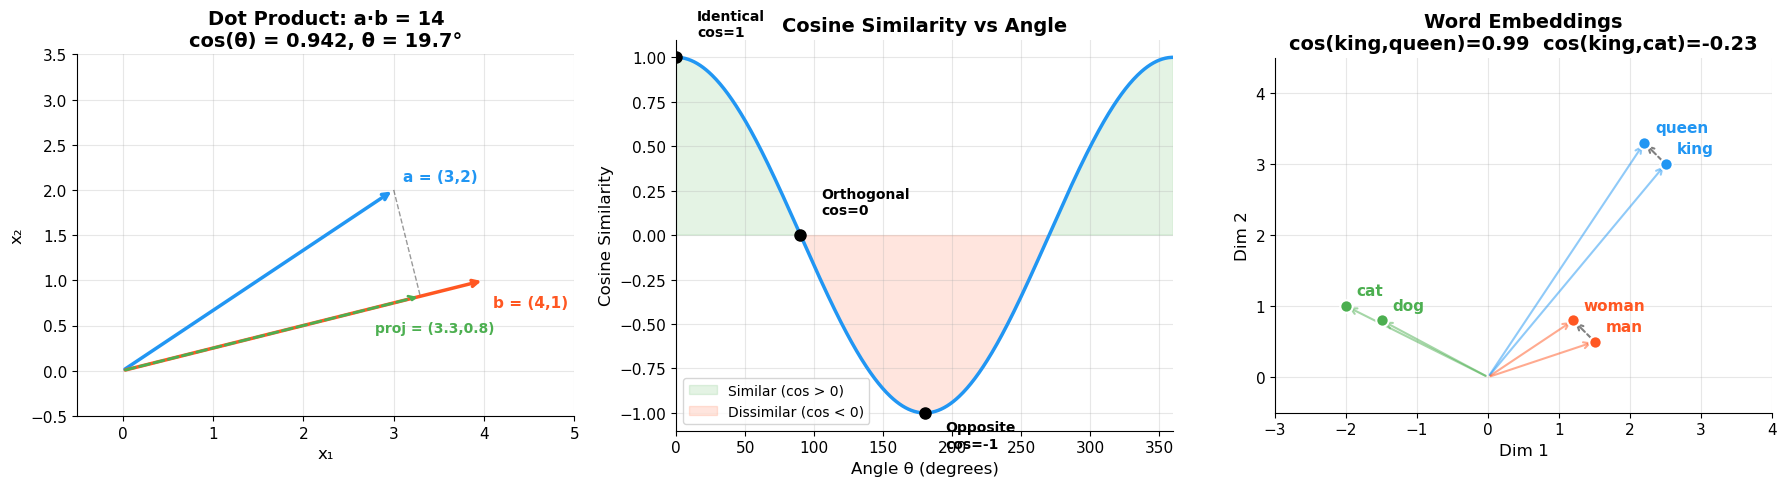

In [2]:
# Dot Product & Cosine Similarity — Geometric Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: Dot product as projection ---
ax = axes[0]
a = np.array([3, 2])
b = np.array([4, 1])

# Projection of a onto b
proj_scalar = np.dot(a, b) / np.linalg.norm(b)
proj_vector = (np.dot(a, b) / np.dot(b, b)) * b

ax.annotate('', xy=a, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=COLORS[0], lw=2.5))
ax.annotate('', xy=b, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=COLORS[1], lw=2.5))
ax.annotate('', xy=proj_vector, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=COLORS[2], lw=2, linestyle='--'))

# Dashed line from a to projection
ax.plot([a[0], proj_vector[0]], [a[1], proj_vector[1]], 'k--', alpha=0.4, linewidth=1)

ax.text(a[0]+0.1, a[1]+0.1, 'a = (3,2)', fontsize=11, color=COLORS[0], fontweight='bold')
ax.text(b[0]+0.1, b[1]-0.3, 'b = (4,1)', fontsize=11, color=COLORS[1], fontweight='bold')
ax.text(proj_vector[0]-0.5, proj_vector[1]-0.4, f'proj = ({proj_vector[0]:.1f},{proj_vector[1]:.1f})',
        fontsize=10, color=COLORS[2], fontweight='bold')

dot_val = np.dot(a, b)
cos_val = dot_val / (np.linalg.norm(a) * np.linalg.norm(b))
theta = np.degrees(np.arccos(cos_val))
ax.set_title(f'Dot Product: a·b = {dot_val}\ncos(θ) = {cos_val:.3f}, θ = {theta:.1f}°', fontweight='bold')
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 3.5)
ax.set_aspect('equal')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# --- Middle: Cosine similarity for different angles ---
ax = axes[1]
angles = np.linspace(0, 360, 500)
cos_vals = np.cos(np.radians(angles))

ax.plot(angles, cos_vals, linewidth=2.5, color=COLORS[0])
ax.fill_between(angles, cos_vals, where=(cos_vals > 0), alpha=0.15, color=COLORS[2], label='Similar (cos > 0)')
ax.fill_between(angles, cos_vals, where=(cos_vals < 0), alpha=0.15, color=COLORS[1], label='Dissimilar (cos < 0)')

# Mark key points
key_angles = [0, 90, 180]
key_labels = ['Identical\ncos=1', 'Orthogonal\ncos=0', 'Opposite\ncos=-1']
for ang, label in zip(key_angles, key_labels):
    cos_v = np.cos(np.radians(ang))
    ax.plot(ang, cos_v, 'ko', markersize=8, zorder=5)
    ax.annotate(label, (ang, cos_v), textcoords='offset points', xytext=(15, 15 if cos_v >= 0 else -25),
                fontsize=10, fontweight='bold')

ax.set_xlabel('Angle θ (degrees)')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Cosine Similarity vs Angle', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 360)

# --- Right: Word embedding similarity example ---
ax = axes[2]
np.random.seed(42)

# Simulated 2D word embeddings
words = {'king': [2.5, 3.0], 'queen': [2.2, 3.3], 'man': [1.5, 0.5],
         'woman': [1.2, 0.8], 'cat': [-2.0, 1.0], 'dog': [-1.5, 0.8]}
word_colors = [COLORS[0], COLORS[0], COLORS[1], COLORS[1], COLORS[2], COLORS[2]]

for (word, vec), color in zip(words.items(), word_colors):
    ax.annotate('', xy=vec, xytext=(0,0), arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.5))
    ax.scatter(*vec, s=80, color=color, zorder=5, edgecolors='white', linewidth=1.5)
    ax.text(vec[0]+0.15, vec[1]+0.15, word, fontsize=11, fontweight='bold', color=color)

# Draw king-queen and man-woman relationships
ax.annotate('', xy=words['queen'], xytext=words['king'],
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='--'))
ax.annotate('', xy=words['woman'], xytext=words['man'],
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='--'))

# Compute similarities
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

sim_kq = cos_sim(words['king'], words['queen'])
sim_kc = cos_sim(words['king'], words['cat'])

ax.set_title(f'Word Embeddings\ncos(king,queen)={sim_kq:.2f}  cos(king,cat)={sim_kc:.2f}', fontweight='bold')
ax.set_xlim(-3, 4); ax.set_ylim(-0.5, 4.5)
ax.set_aspect('equal')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')

plt.tight_layout()
plt.show()

## 1.2 Matrices — Linear Transformations

A matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ is a **linear transformation** from $\mathbb{R}^n \to \mathbb{R}^m$.

$$\mathbf{y} = \mathbf{A}\mathbf{x}$$

Every linear layer in a neural network is a matrix multiplication (plus bias):

$$\mathbf{h} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

### Key Matrix Properties

| Property | Definition | ML Relevance |
|----------|-----------|-------------|
| **Rank** | Number of linearly independent rows/columns | Measures information content; low-rank ≈ compressible (LoRA!) |
| **Trace** | $\text{tr}(\mathbf{A}) = \sum_i a_{ii}$ | Sum of eigenvalues; used in regularization |
| **Determinant** | $\det(\mathbf{A})$ | Volume scaling factor; 0 means singular (non-invertible) |
| **Transpose** | $(\mathbf{A}^T)_{ij} = a_{ji}$ | Gradient computation in backprop |
| **Inverse** | $\mathbf{A}^{-1}\mathbf{A} = \mathbf{I}$ | Normal equations, Gaussian processes |
| **Orthogonal** | $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$ | Preserves norms & angles; used in initialization |

### Types of Matrices in ML

| Matrix Type | Properties | Where You'll See It |
|------------|-----------|--------------------|
| **Symmetric** | $\mathbf{A} = \mathbf{A}^T$ | Covariance matrices, Hessians |
| **Positive Definite** | All eigenvalues > 0 | Covariance matrices, kernels |
| **Diagonal** | Non-zero only on diagonal | Scaling, batch norm |
| **Sparse** | Mostly zeros | Graph adjacency, attention masks |
| **Low-Rank** | $\text{rank}(\mathbf{A}) \ll \min(m,n)$ | LoRA, matrix factorization |

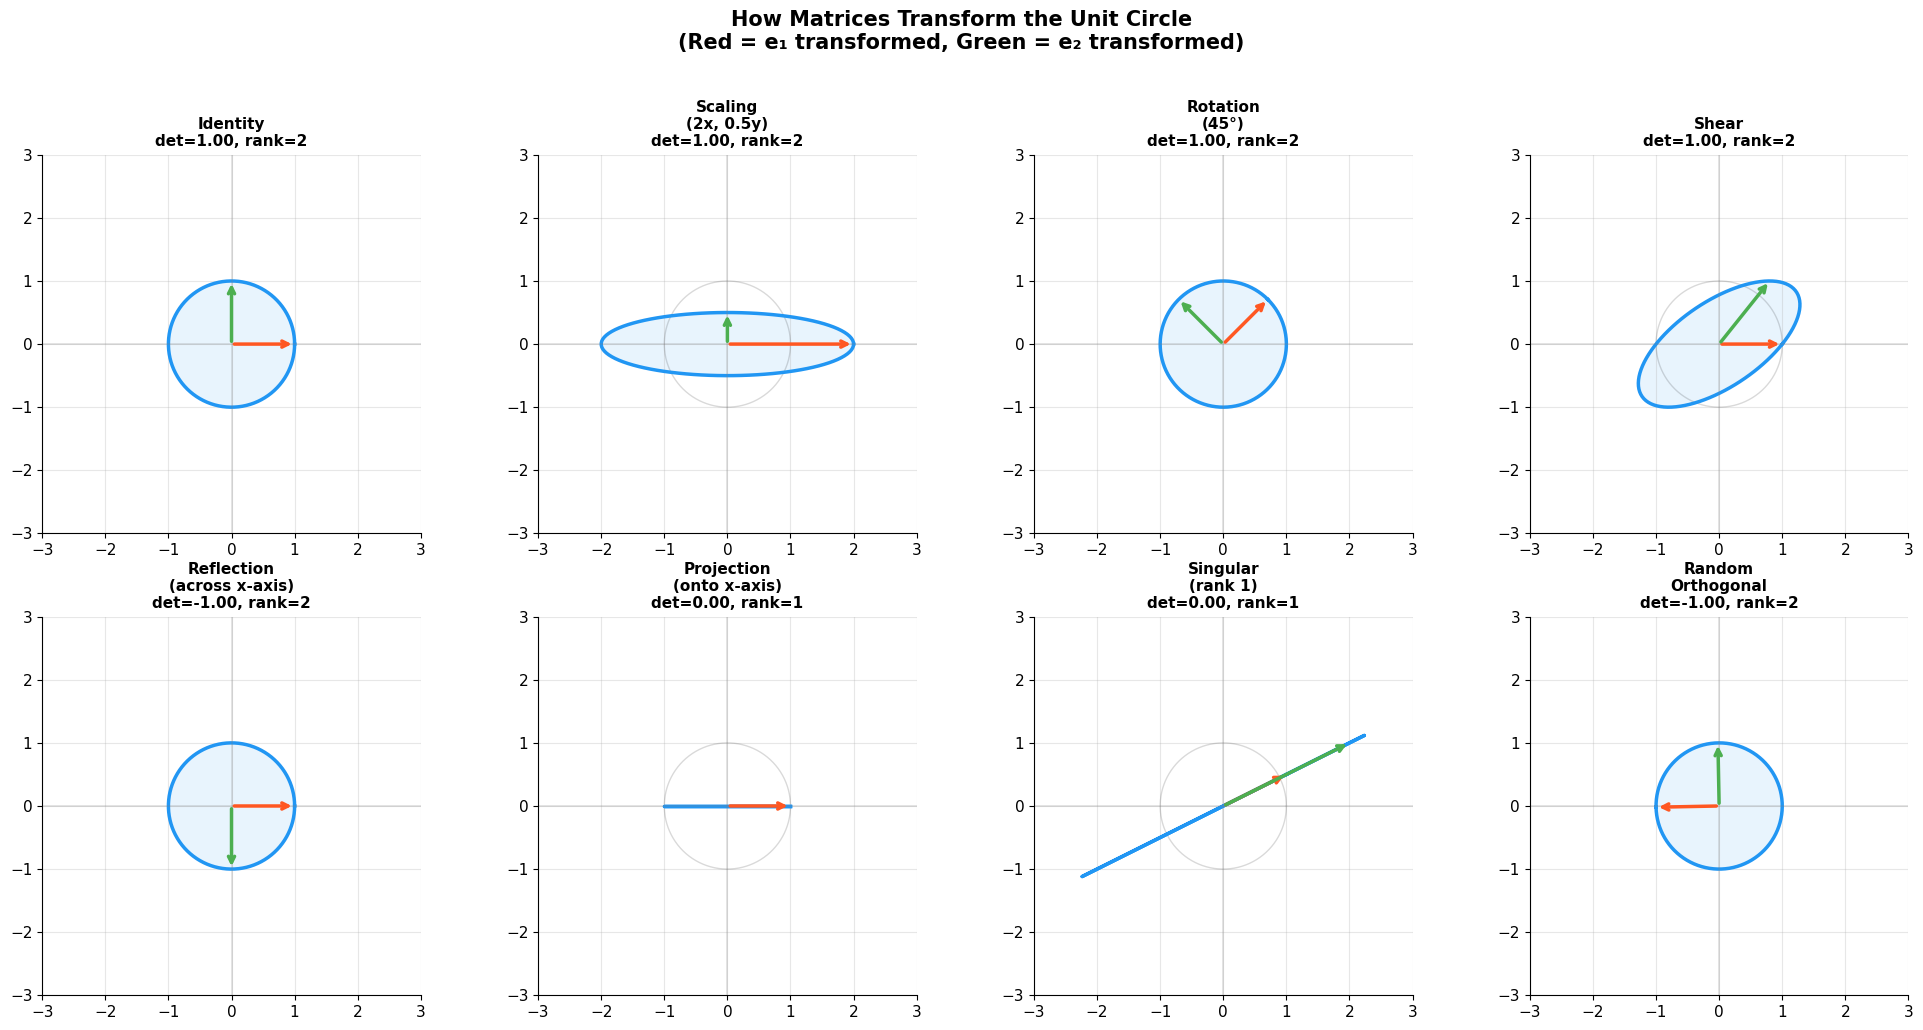

In [3]:
# Linear Transformations — Watch matrices transform space
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Create a grid + unit circle to show transformations
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])  # 2xN

# Grid points
grid_x, grid_y = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-2, 2, 10))
grid = np.array([grid_x.ravel(), grid_y.ravel()])  # 2xN

# Special vectors to track
basis = np.array([[1, 0], [0, 1]]).T  # 2x2, columns are e1, e2

transforms = [
    ('Identity', np.eye(2)),
    ('Scaling\n(2x, 0.5y)', np.array([[2, 0], [0, 0.5]])),
    ('Rotation\n(45°)', np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
                                   [np.sin(np.pi/4), np.cos(np.pi/4)]])),
    ('Shear', np.array([[1, 0.8], [0, 1]])),
    ('Reflection\n(across x-axis)', np.array([[1, 0], [0, -1]])),
    ('Projection\n(onto x-axis)', np.array([[1, 0], [0, 0]])),
    ('Singular\n(rank 1)', np.array([[1, 2], [0.5, 1]])),
    ('Random\nOrthogonal', None),  # Will compute
]

# Generate random orthogonal matrix
np.random.seed(7)
Q, _ = np.linalg.qr(np.random.randn(2, 2))
transforms[-1] = ('Random\nOrthogonal', Q)

for idx, (name, A) in enumerate(transforms):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    
    # Transform the circle
    transformed_circle = A @ circle
    transformed_basis = A @ basis
    
    # Plot original circle (faint)
    ax.plot(circle[0], circle[1], 'k-', alpha=0.15, linewidth=1)
    
    # Plot transformed circle
    ax.plot(transformed_circle[0], transformed_circle[1], '-', color=COLORS[0], linewidth=2.5)
    ax.fill(transformed_circle[0], transformed_circle[1], color=COLORS[0], alpha=0.1)
    
    # Plot transformed basis vectors
    ax.annotate('', xy=transformed_basis[:, 0], xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=COLORS[1], lw=2.5))
    ax.annotate('', xy=transformed_basis[:, 1], xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=COLORS[2], lw=2.5))
    
    det = np.linalg.det(A)
    rank = np.linalg.matrix_rank(A)
    ax.set_title(f'{name}\ndet={det:.2f}, rank={rank}', fontweight='bold', fontsize=11)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.3)
    ax.axvline(0, color='gray', linewidth=0.3)

plt.suptitle('How Matrices Transform the Unit Circle\n'
             '(Red = e₁ transformed, Green = e₂ transformed)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.3 Eigendecomposition

An eigenvector $\mathbf{v}$ of matrix $\mathbf{A}$ is a direction that is **only scaled** (not rotated) by $\mathbf{A}$:

$$\mathbf{A}\mathbf{v} = \lambda \mathbf{v}$$

where $\lambda$ is the **eigenvalue** — the scale factor.

### Eigendecomposition
For a square matrix $\mathbf{A}$ with $n$ linearly independent eigenvectors:

$$\mathbf{A} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^{-1}$$

where $\mathbf{V} = [\mathbf{v}_1 | \mathbf{v}_2 | \cdots | \mathbf{v}_n]$ and $\mathbf{\Lambda} = \text{diag}(\lambda_1, \ldots, \lambda_n)$.

For **symmetric** matrices ($\mathbf{A} = \mathbf{A}^T$), the **Spectral Theorem** guarantees:
- All eigenvalues are **real**
- Eigenvectors are **orthogonal**: $\mathbf{A} = \mathbf{Q} \mathbf{\Lambda} \mathbf{Q}^T$

### Why Eigenvalues Matter in ML

| Application | How Eigenvalues Are Used |
|------------|------------------------|
| **PCA** | Eigenvectors of covariance matrix = principal components; eigenvalues = variance explained |
| **Spectral Clustering** | Eigenvectors of graph Laplacian reveal cluster structure |
| **Hessian Analysis** | Eigenvalues of Hessian tell you about loss surface curvature |
| **Stability** | Eigenvalues of recurrent weight matrix: $|\lambda| > 1$ → exploding, $|\lambda| < 1$ → vanishing |
| **Condition Number** | $\kappa = |\lambda_{\max}| / |\lambda_{\min}|$ — higher = harder to optimize |

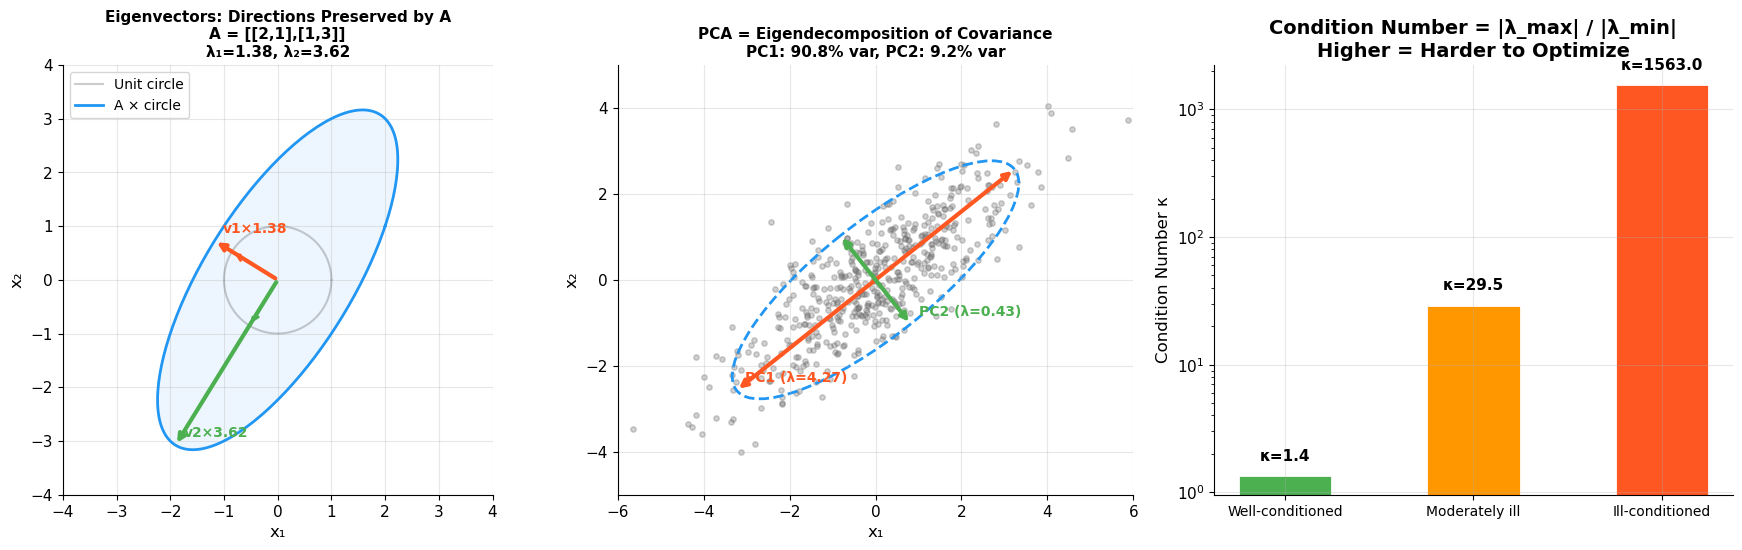

In [4]:
# Eigendecomposition — Geometric Intuition
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Left: Eigenvectors are preserved directions ---
ax = axes[0]
A = np.array([[2, 1], [1, 3]])
eigenvalues, eigenvectors = np.linalg.eig(A)

# Plot unit circle and its transformation
theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])
ellipse = A @ circle

ax.plot(circle[0], circle[1], 'k-', alpha=0.2, linewidth=1.5, label='Unit circle')
ax.plot(ellipse[0], ellipse[1], '-', color=COLORS[0], linewidth=2, label='A × circle')
ax.fill(ellipse[0], ellipse[1], color=COLORS[0], alpha=0.08)

# Plot eigenvectors (before and after)
for i, (val, vec, color) in enumerate(zip(eigenvalues, eigenvectors.T, [COLORS[1], COLORS[2]])):
    # Original eigenvector (on unit circle)
    ax.annotate('', xy=vec, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2, linestyle='--'))
    # Transformed eigenvector (scaled by eigenvalue)
    transformed = val * vec
    ax.annotate('', xy=transformed, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=color, lw=3))
    ax.text(transformed[0]+0.15, transformed[1]+0.15,
            f'v{i+1}×{val:.2f}', fontsize=10, color=color, fontweight='bold')

ax.set_title(f'Eigenvectors: Directions Preserved by A\nA = [[2,1],[1,3]]\nλ₁={eigenvalues[0]:.2f}, λ₂={eigenvalues[1]:.2f}',
             fontweight='bold', fontsize=11)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.legend(fontsize=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# --- Middle: Covariance matrix eigendecomposition ---
ax = axes[1]
np.random.seed(42)
# Generate correlated 2D data
cov_matrix = np.array([[3, 2], [2, 2]])
data = np.random.multivariate_normal([0, 0], cov_matrix, 500)

ax.scatter(data[:, 0], data[:, 1], alpha=0.3, s=15, color='#666')

# Compute eigenvectors of covariance
cov_est = np.cov(data.T)
evals, evecs = np.linalg.eigh(cov_est)
# Sort by eigenvalue descending
idx = np.argsort(evals)[::-1]
evals, evecs = evals[idx], evecs[:, idx]

# Plot principal components
for i, (val, vec, color) in enumerate(zip(evals, evecs.T, [COLORS[1], COLORS[2]])):
    scale = np.sqrt(val) * 2  # 2 standard deviations
    ax.annotate('', xy=vec*scale, xytext=-vec*scale,
                arrowprops=dict(arrowstyle='<->', color=color, lw=3))
    ax.text(vec[0]*scale+0.2, vec[1]*scale+0.2,
            f'PC{i+1} (λ={val:.2f})', fontsize=10, color=color, fontweight='bold')

# Draw covariance ellipse
angle = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))
ell = Ellipse((0, 0), width=2*2*np.sqrt(evals[0]), height=2*2*np.sqrt(evals[1]),
              angle=angle, facecolor='none', edgecolor=COLORS[0], linewidth=2, linestyle='--')
ax.add_patch(ell)

var_explained = evals / evals.sum() * 100
ax.set_title(f'PCA = Eigendecomposition of Covariance\nPC1: {var_explained[0]:.1f}% var, PC2: {var_explained[1]:.1f}% var',
             fontweight='bold', fontsize=11)
ax.set_xlim(-6, 6); ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# --- Right: Eigenvalue spectrum and condition number ---
ax = axes[2]
np.random.seed(42)

# Well-conditioned vs ill-conditioned
matrices = {
    'Well-conditioned': np.array([[2, 0.1], [0.1, 1.5]]),
    'Moderately ill': np.array([[10, 3], [3, 0.5]]),
    'Ill-conditioned': np.array([[100, 50], [50, 25.1]]),
}

x_pos = np.arange(len(matrices))
cond_nums = []
for name, M in matrices.items():
    evals_m = np.linalg.eigvalsh(M)
    cond = max(abs(evals_m)) / max(min(abs(evals_m)), 1e-10)
    cond_nums.append(cond)

bars = ax.bar(x_pos, cond_nums, color=[COLORS[2], COLORS[4], COLORS[1]], 
              edgecolor='white', linewidth=2, width=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(list(matrices.keys()), fontsize=10)
ax.set_ylabel('Condition Number κ', fontsize=12)
ax.set_title('Condition Number = |λ_max| / |λ_min|\nHigher = Harder to Optimize', fontweight='bold')
ax.set_yscale('log')

for bar, cn in zip(bars, cond_nums):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            f'κ={cn:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 1.4 Singular Value Decomposition (SVD)

The **most general** matrix decomposition — works for **any** matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$:

$$\boxed{\mathbf{A} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T}$$

| Component | Shape | Properties | Interpretation |
|-----------|-------|-----------|---------------|
| $\mathbf{U}$ | $m \times m$ | Orthogonal ($\mathbf{U}^T\mathbf{U} = \mathbf{I}$) | Left singular vectors (output space) |
| $\mathbf{\Sigma}$ | $m \times n$ | Diagonal, non-negative, sorted | Singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$ |
| $\mathbf{V}^T$ | $n \times n$ | Orthogonal ($\mathbf{V}^T\mathbf{V} = \mathbf{I}$) | Right singular vectors (input space) |

### Low-Rank Approximation (Eckart-Young Theorem)

The best rank-$k$ approximation of $\mathbf{A}$ (in Frobenius/spectral norm) is obtained by keeping only the top $k$ singular values:

$$\mathbf{A}_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

### SVD in ML

| Application | How SVD Is Used |
|------------|----------------|
| **PCA** | SVD of centered data matrix (more numerically stable than eigendecomposition) |
| **LoRA** | Low-rank adaptation: $\mathbf{W} + \Delta\mathbf{W} \approx \mathbf{W} + \mathbf{B}\mathbf{A}$ where $\mathbf{B} \in \mathbb{R}^{d \times r}$, $\mathbf{A} \in \mathbb{R}^{r \times d}$ |
| **Dimensionality Reduction** | Keep top-$k$ components for compression |
| **Recommender Systems** | Matrix factorization of user-item matrix |
| **Image Compression** | Each color channel = matrix → SVD → keep top singular values |

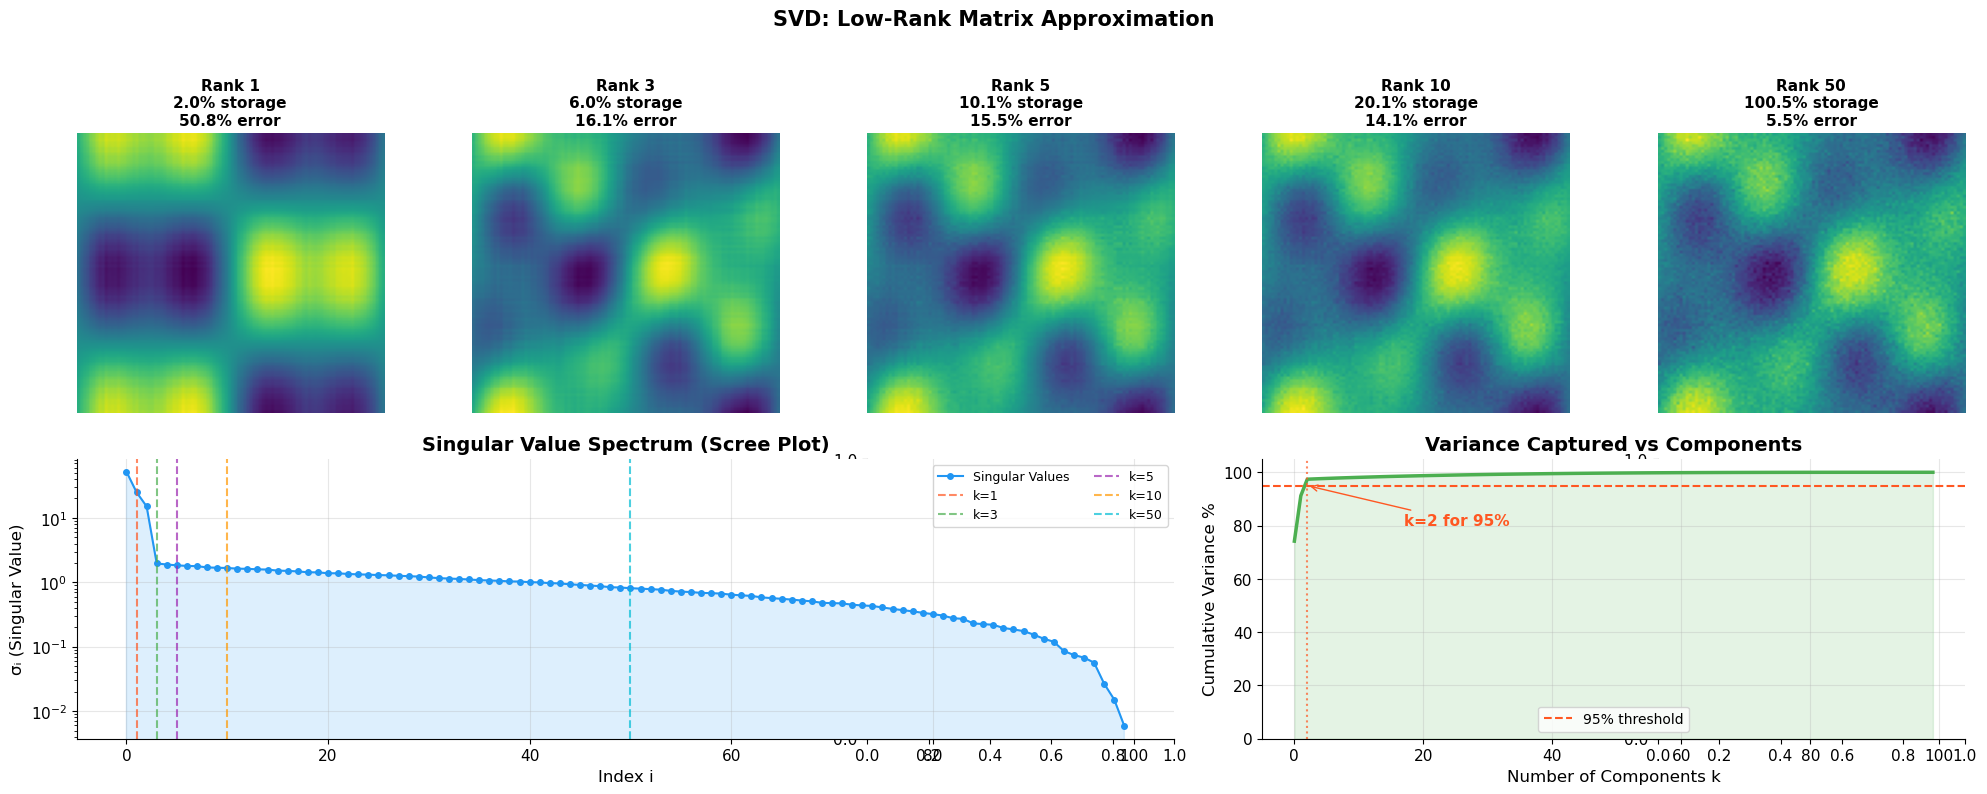

In [5]:
# SVD — Image Compression Demo
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Create a synthetic grayscale "image" (a smooth pattern)
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
# Interesting pattern with varying frequency content
image = (np.sin(X) * np.cos(Y) + 
         0.5 * np.sin(2*X) * np.cos(2*Y) + 
         0.3 * np.sin(3*X + Y) +
         0.1 * np.random.randn(100, 100))

# Compute SVD
U, S, Vt = np.linalg.svd(image, full_matrices=False)

# Show original and reconstructions at different ranks
ranks = [1, 3, 5, 10, 50]

for i, k in enumerate(ranks):
    # Reconstruct with rank k
    reconstructed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    
    # Compression ratio
    original_params = image.shape[0] * image.shape[1]  # 100*100 = 10000
    svd_params = k * (image.shape[0] + image.shape[1] + 1)  # k*(100 + 100 + 1)
    ratio = svd_params / original_params * 100
    
    # Error
    error = np.linalg.norm(image - reconstructed, 'fro') / np.linalg.norm(image, 'fro') * 100
    
    ax = axes[0][i]
    ax.imshow(reconstructed, cmap='viridis', aspect='auto')
    ax.set_title(f'Rank {k}\n{ratio:.1f}% storage\n{error:.1f}% error', fontweight='bold', fontsize=11)
    ax.axis('off')

# Bottom row: singular value spectrum
axes[1][0].remove()
axes[1][1].remove()
ax_spec = fig.add_subplot(2, 5, (6, 8))

ax_spec.plot(S, 'o-', color=COLORS[0], markersize=4, linewidth=1.5, label='Singular Values')
ax_spec.fill_between(range(len(S)), S, alpha=0.15, color=COLORS[0])
for k, color in zip(ranks, [COLORS[1], COLORS[2], COLORS[3], COLORS[4], COLORS[5]]):
    ax_spec.axvline(k, color=color, linestyle='--', alpha=0.7, linewidth=1.5, label=f'k={k}')
ax_spec.set_xlabel('Index i', fontsize=12)
ax_spec.set_ylabel('σᵢ (Singular Value)', fontsize=12)
ax_spec.set_title('Singular Value Spectrum (Scree Plot)', fontweight='bold')
ax_spec.legend(fontsize=9, ncol=2)
ax_spec.set_yscale('log')

# Cumulative variance
axes[1][3].remove()
ax_cum = fig.add_subplot(2, 5, (9, 10))
cumulative = np.cumsum(S**2) / np.sum(S**2) * 100
ax_cum.plot(cumulative, linewidth=2.5, color=COLORS[2])
ax_cum.fill_between(range(len(cumulative)), cumulative, alpha=0.15, color=COLORS[2])
ax_cum.axhline(95, color=COLORS[1], linestyle='--', label='95% threshold')
k_95 = np.argmax(cumulative >= 95)
ax_cum.axvline(k_95, color=COLORS[1], linestyle=':', alpha=0.7)
ax_cum.annotate(f'k={k_95} for 95%', xy=(k_95, 95), xytext=(k_95+15, 80),
                arrowprops=dict(arrowstyle='->', color=COLORS[1]),
                fontsize=11, fontweight='bold', color=COLORS[1])
ax_cum.set_xlabel('Number of Components k')
ax_cum.set_ylabel('Cumulative Variance %')
ax_cum.set_title('Variance Captured vs Components', fontweight='bold')
ax_cum.legend(fontsize=10)
ax_cum.set_ylim(0, 105)

plt.suptitle('SVD: Low-Rank Matrix Approximation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.5 PCA — Principal Component Analysis

PCA finds the **directions of maximum variance** in data. It's equivalent to eigendecomposition of the covariance matrix, or SVD of the centered data matrix.

### Algorithm

1. **Center** the data: $\mathbf{X}_{centered} = \mathbf{X} - \bar{\mathbf{X}}$
2. **Compute** covariance: $\mathbf{C} = \frac{1}{n-1}\mathbf{X}_{centered}^T \mathbf{X}_{centered}$
3. **Eigendecompose:** $\mathbf{C} = \mathbf{V}\mathbf{\Lambda}\mathbf{V}^T$
4. **Project:** $\mathbf{Z} = \mathbf{X}_{centered} \mathbf{V}_k$ (keep top $k$ eigenvectors)

### Equivalence with SVD
If $\mathbf{X}_{centered} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^T$, then:
- Principal components = columns of $\mathbf{V}$
- Eigenvalues of covariance = $\frac{\sigma_i^2}{n-1}$
- Projected data = $\mathbf{U}\mathbf{\Sigma}$ (or equivalently $\mathbf{X}\mathbf{V}$)

> **Why SVD over Eigendecomposition?** Numerically more stable, works directly on the data matrix (no need to form $\mathbf{X}^T\mathbf{X}$ which squares the condition number).

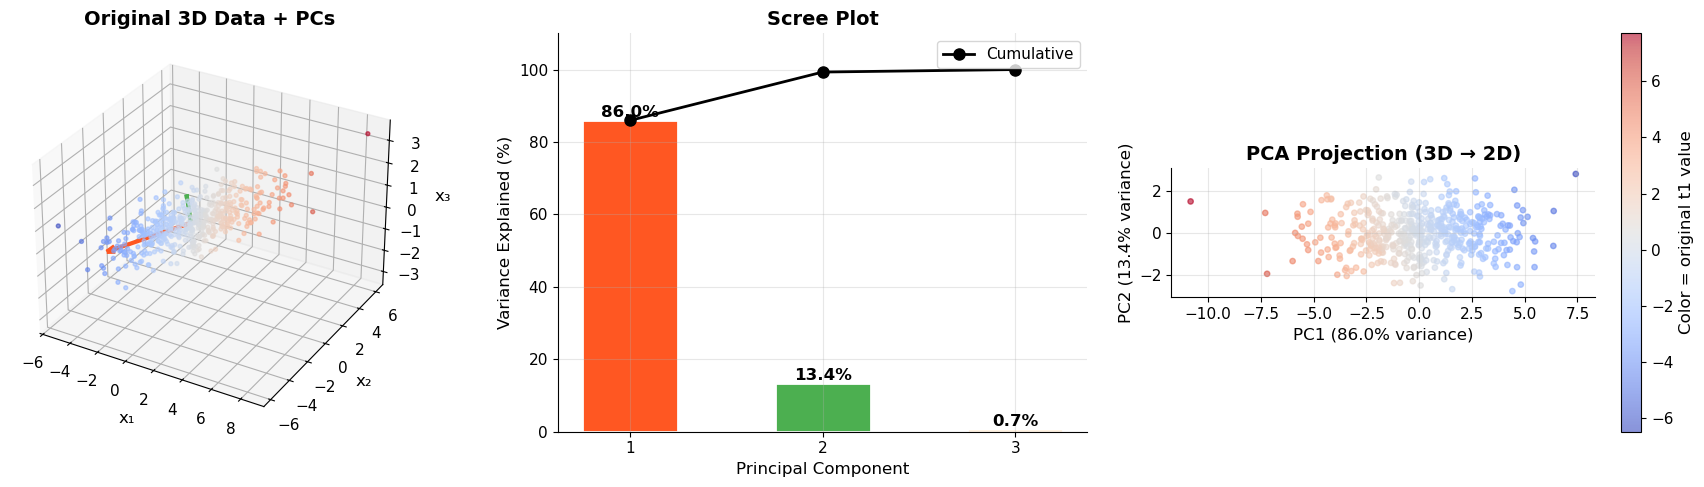

Variance Explained: PC1=86.0%, PC2=13.4%, PC3=0.7%
Keeping 2 PCs captures 99.3% of total variance!


In [6]:
# PCA — Step by Step on 3D Data
np.random.seed(42)

# Generate 3D data that lies mostly in a 2D plane
n = 500
# Two main directions + noise in third direction
t1 = np.random.randn(n) * 2
t2 = np.random.randn(n) * 1
noise = np.random.randn(n) * 0.2

# Create 3D data
X = np.column_stack([
    t1 + 0.5*t2,
    0.8*t1 - 0.3*t2 + noise,
    0.2*t1 + 0.9*t2 + noise
])

# Step 1: Center
X_centered = X - X.mean(axis=0)

# Step 2: SVD (preferred over eigendecomposition)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
eigenvalues = S**2 / (n - 1)
explained_var = eigenvalues / eigenvalues.sum() * 100

# Step 3: Project to 2D
X_2d = X_centered @ Vt[:2].T

fig = plt.figure(figsize=(18, 5))

# --- Left: 3D scatter ---
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t1, cmap='coolwarm', s=8, alpha=0.6)

# Plot PC vectors from the mean
mean = X.mean(axis=0)
for i, (pc, color) in enumerate(zip(Vt, [COLORS[1], COLORS[2], COLORS[4]])):
    scale = np.sqrt(eigenvalues[i]) * 2
    ax1.quiver(*mean, *(pc*scale), color=color, linewidth=3, arrow_length_ratio=0.1)

ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂'); ax1.set_zlabel('x₃')
ax1.set_title('Original 3D Data + PCs', fontweight='bold')

# --- Middle: Explained variance ---
ax2 = fig.add_subplot(132)
bars = ax2.bar(range(1, 4), explained_var, color=[COLORS[1], COLORS[2], COLORS[4]],
               edgecolor='white', linewidth=2, width=0.5)
ax2.plot(range(1, 4), np.cumsum(explained_var), 'ko-', linewidth=2, markersize=8, label='Cumulative')
for bar, ev in zip(bars, explained_var):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{ev:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('Scree Plot', fontweight='bold')
ax2.set_ylim(0, 110)
ax2.set_xticks(range(1, 4))
ax2.legend(fontsize=11)

# --- Right: 2D projection ---
ax3 = fig.add_subplot(133)
scatter = ax3.scatter(X_2d[:, 0], X_2d[:, 1], c=t1, cmap='coolwarm', s=15, alpha=0.6)
ax3.set_xlabel(f'PC1 ({explained_var[0]:.1f}% variance)')
ax3.set_ylabel(f'PC2 ({explained_var[1]:.1f}% variance)')
ax3.set_title('PCA Projection (3D → 2D)', fontweight='bold')
ax3.set_aspect('equal')
plt.colorbar(scatter, ax=ax3, label='Color = original t1 value')

plt.tight_layout()
plt.show()

print(f'Variance Explained: PC1={explained_var[0]:.1f}%, PC2={explained_var[1]:.1f}%, PC3={explained_var[2]:.1f}%')
print(f'Keeping 2 PCs captures {explained_var[:2].sum():.1f}% of total variance!')

---
# 2. 📐 Matrix Calculus & Gradients

Calculus tells us *how things change*. In ML, we need to know how the **loss changes** with respect to every **parameter** — so we can update them to reduce the loss. This is the mathematical engine behind training.

---

## 2.1 Gradient — The Direction of Steepest Ascent

For a scalar function $f: \mathbb{R}^n \to \mathbb{R}$, the gradient is a vector of all partial derivatives:

$$\nabla f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$$

**Key properties:**
- Points in the direction of **steepest ascent** (so $-\nabla f$ = steepest descent)
- Magnitude $\|\nabla f\|$ = rate of change in that direction
- Perpendicular to **level sets** (contour lines) of $f$

## 2.2 The Jacobian Matrix

For a vector-valued function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the Jacobian contains all partial derivatives:

$$\mathbf{J} = \frac{\partial \mathbf{f}}{\partial \mathbf{x}} = \begin{bmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n} \end{bmatrix} \in \mathbb{R}^{m \times n}$$

- For scalar $f$ ($m=1$): Jacobian = gradient (as a row vector)
- Each row $i$: gradient of $f_i$ with respect to all inputs
- Each column $j$: how all outputs change when $x_j$ changes

## 2.3 The Hessian Matrix

The matrix of **second derivatives** — describes the **curvature** of the loss landscape:

$$\mathbf{H} = \nabla^2 f = \begin{bmatrix} \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots \\ \frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

- **Symmetric** (if $f$ is smooth): $\mathbf{H}_{ij} = \mathbf{H}_{ji}$
- **Positive definite** → local minimum (bowl shape)
- **Negative definite** → local maximum (inverted bowl)
- **Indefinite** (mixed eigenvalues) → saddle point
- Eigenvalues of $\mathbf{H}$ = curvature along each eigenvector direction

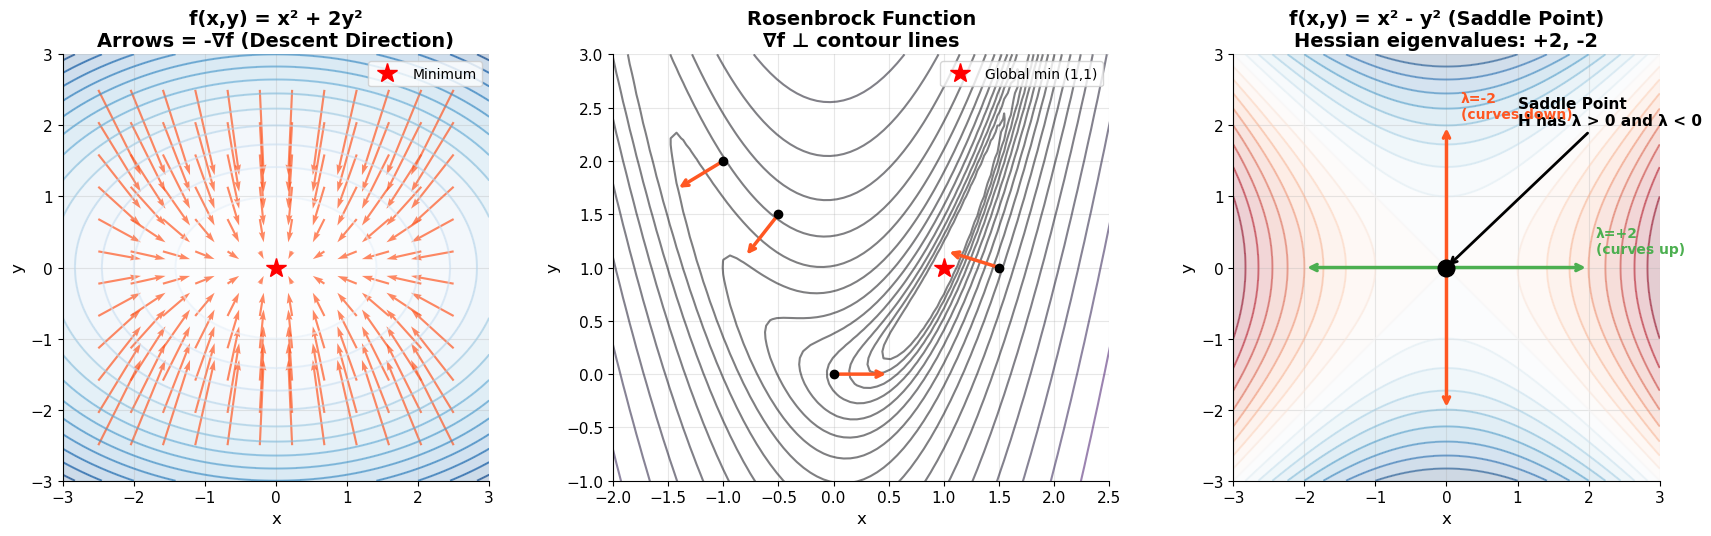

Key Insight: In high dimensions, saddle points are MUCH more common than local minima.
This is why SGD with momentum works well — it can escape saddle points!


In [7]:
# Gradients, Contours & The Hessian — Visual Exploration
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Left: Gradient field on a simple loss surface ---
ax = axes[0]
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# Loss function: f(x,y) = x^2 + 2y^2 (elliptical bowl)
Z = X**2 + 2*Y**2

ax.contour(X, Y, Z, levels=15, cmap='Blues', alpha=0.6)
ax.contourf(X, Y, Z, levels=15, cmap='Blues', alpha=0.2)

# Gradient field (subsample for clarity)
xg, yg = np.meshgrid(np.linspace(-2.5, 2.5, 12), np.linspace(-2.5, 2.5, 12))
gx = 2 * xg  # df/dx
gy = 4 * yg   # df/dy
# Negative gradient (descent direction)
ax.quiver(xg, yg, -gx, -gy, color=COLORS[1], alpha=0.7, scale=50)

ax.plot(0, 0, 'r*', markersize=15, zorder=5, label='Minimum')
ax.set_title('f(x,y) = x² + 2y²\nArrows = -∇f (Descent Direction)', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
ax.legend(fontsize=10)

# --- Middle: Gradient perpendicular to contours ---
ax = axes[1]
# Rosenbrock-like function
Z2 = (1-X)**2 + 5*(Y - X**2)**2

ax.contour(X, Y, Z2, levels=np.logspace(-0.5, 3, 20), cmap='inferno', alpha=0.5)

# Gradient at specific points
points = [(-1, 2), (0, 0), (1.5, 1), (-0.5, 1.5)]
for px, py in points:
    gx_p = -2*(1-px) + 5*2*(py - px**2)*(-2*px)
    gy_p = 5*2*(py - px**2)
    norm = np.sqrt(gx_p**2 + gy_p**2)
    if norm > 0:
        gx_n, gy_n = -gx_p/norm * 0.5, -gy_p/norm * 0.5
    else:
        gx_n, gy_n = 0, 0
    ax.annotate('', xy=(px + gx_n, py + gy_n), xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color=COLORS[1], lw=2.5))
    ax.plot(px, py, 'ko', markersize=6, zorder=5)

ax.plot(1, 1, 'r*', markersize=15, zorder=5, label='Global min (1,1)')
ax.set_title('Rosenbrock Function\n∇f ⊥ contour lines', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=10)
ax.set_xlim(-2, 2.5); ax.set_ylim(-1, 3)

# --- Right: Saddle point (Hessian has mixed eigenvalues) ---
ax = axes[2]
Z3 = X**2 - Y**2  # Saddle: f(x,y) = x^2 - y^2

ax.contour(X, Y, Z3, levels=20, cmap='RdBu_r', alpha=0.5)
ax.contourf(X, Y, Z3, levels=20, cmap='RdBu_r', alpha=0.2)

ax.plot(0, 0, 'ko', markersize=12, zorder=5)
ax.annotate('Saddle Point\nH has λ > 0 and λ < 0', xy=(0, 0), xytext=(1, 2),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            fontsize=11, fontweight='bold')

# Eigenvector directions of Hessian [[2,0],[0,-2]]
ax.annotate('', xy=(2, 0), xytext=(-2, 0),
            arrowprops=dict(arrowstyle='<->', color=COLORS[2], lw=2.5))
ax.annotate('', xy=(0, 2), xytext=(0, -2),
            arrowprops=dict(arrowstyle='<->', color=COLORS[1], lw=2.5))
ax.text(2.1, 0.2, 'λ=+2\n(curves up)', color=COLORS[2], fontsize=10, fontweight='bold')
ax.text(0.2, 2.1, 'λ=-2\n(curves down)', color=COLORS[1], fontsize=10, fontweight='bold')

ax.set_title('f(x,y) = x² - y² (Saddle Point)\nHessian eigenvalues: +2, -2', fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print('Key Insight: In high dimensions, saddle points are MUCH more common than local minima.')
print('This is why SGD with momentum works well — it can escape saddle points!')

## 2.4 The Chain Rule — Backbone of Backpropagation

### Scalar Chain Rule
If $y = f(g(x))$:

$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$$

### Vector Chain Rule (Jacobian Form)
If $\mathbf{y} = \mathbf{f}(\mathbf{g}(\mathbf{x}))$:

$$\frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \frac{\partial \mathbf{y}}{\partial \mathbf{g}} \cdot \frac{\partial \mathbf{g}}{\partial \mathbf{x}} = \mathbf{J}_f \cdot \mathbf{J}_g$$

### Backpropagation is Just the Chain Rule!

A neural network is a composition of functions:

$$\mathcal{L} = L(f_n(f_{n-1}(\cdots f_2(f_1(\mathbf{x})))))$$

The gradient with respect to layer $i$'s parameters:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}_i} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}_n} \cdot \frac{\partial \mathbf{a}_n}{\partial \mathbf{a}_{n-1}} \cdots \frac{\partial \mathbf{a}_{i+1}}{\partial \mathbf{a}_i} \cdot \frac{\partial \mathbf{a}_i}{\partial \mathbf{W}_i}$$

### Common Derivatives in ML

| Function | Derivative | Notes |
|----------|-----------|-------|
| $\mathbf{y} = \mathbf{W}\mathbf{x}$ | $\frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \mathbf{W}$, $\frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \frac{\partial \mathcal{L}}{\partial \mathbf{y}} \mathbf{x}^T$ | Linear layer |
| $y = \sigma(z)$ | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ | Sigmoid |
| $y = \text{ReLU}(z)$ | $y' = \mathbb{1}[z > 0]$ | ReLU |
| $\mathcal{L} = -\log(\hat{y}_c)$ | $\frac{\partial \mathcal{L}}{\partial z_i} = \hat{y}_i - y_i$ | Softmax + Cross-Entropy (elegant!) |
| $\mathcal{L} = \|\mathbf{y} - \hat{\mathbf{y}}\|^2$ | $\frac{\partial \mathcal{L}}{\partial \hat{\mathbf{y}}} = 2(\hat{\mathbf{y}} - \mathbf{y})$ | MSE |

In [8]:
# Backpropagation — Manual Implementation of a 2-Layer Network
np.random.seed(42)

# Simple 2-layer network: input(2) -> hidden(3) -> output(1)
# Forward: h = ReLU(W1·x + b1), y_hat = sigmoid(W2·h + b2)

# Initialize
W1 = np.random.randn(3, 2) * 0.5
b1 = np.zeros((3, 1))
W2 = np.random.randn(1, 3) * 0.5
b2 = np.zeros((1, 1))

# Input and target
x = np.array([[1.0], [0.5]])   # Shape: (2, 1)
y = np.array([[1.0]])           # Shape: (1, 1)

print('=== FORWARD PASS ===')
print(f'Input x = {x.flatten()}')

# Layer 1: Linear + ReLU
z1 = W1 @ x + b1
a1 = np.maximum(0, z1)  # ReLU
print(f'\nLayer 1:')
print(f'  z1 = W1·x + b1 = {z1.flatten()}')
print(f'  a1 = ReLU(z1)  = {a1.flatten()}')

# Layer 2: Linear + Sigmoid
z2 = W2 @ a1 + b2
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid
print(f'\nLayer 2:')
print(f'  z2 = W2·a1 + b2 = {z2.flatten()}')
print(f'  y_hat = sigmoid(z2) = {a2.flatten()}')

# Loss: Binary Cross-Entropy
loss = -(y * np.log(a2) + (1 - y) * np.log(1 - a2))
print(f'\nLoss (BCE) = {loss.item():.6f}')

print('\n=== BACKWARD PASS (Chain Rule) ===')

# dL/da2 = -(y/a2 - (1-y)/(1-a2))
dL_da2 = -(y / a2 - (1 - y) / (1 - a2))
print(f'dL/da2 = {dL_da2.flatten()}')

# da2/dz2 = sigmoid(z2)(1-sigmoid(z2))
da2_dz2 = a2 * (1 - a2)
dL_dz2 = dL_da2 * da2_dz2  # This simplifies to a2 - y!
print(f'dL/dz2 = dL/da2 * da2/dz2 = {dL_dz2.flatten()} (= y_hat - y = {(a2-y).flatten()})')

# dL/dW2 = dL/dz2 * a1^T
dL_dW2 = dL_dz2 @ a1.T
print(f'\ndL/dW2 = dL/dz2 · a1^T:')
print(f'  {dL_dW2}')

# dL/db2 = dL/dz2
dL_db2 = dL_dz2

# Backprop to layer 1
# dL/da1 = W2^T · dL/dz2
dL_da1 = W2.T @ dL_dz2

# dL/dz1 = dL/da1 * ReLU'(z1)
dL_dz1 = dL_da1 * (z1 > 0).astype(float)  # ReLU derivative
print(f'\nBackprop to Layer 1:')
print(f'  dL/dz1 = {dL_dz1.flatten()}')

# dL/dW1 = dL/dz1 · x^T
dL_dW1 = dL_dz1 @ x.T
print(f'  dL/dW1 shape = {dL_dW1.shape}')

print('\n--- Gradient Summary ---')
print(f'  ||dL/dW1|| = {np.linalg.norm(dL_dW1):.6f}')
print(f'  ||dL/dW2|| = {np.linalg.norm(dL_dW2):.6f}')
print(f'  Total parameters: {W1.size + b1.size + W2.size + b2.size}')

=== FORWARD PASS ===
Input x = [1.  0.5]

Layer 1:
  z1 = W1·x + b1 = [ 0.213791    0.70460173 -0.17561093]
  a1 = ReLU(z1)  = [0.213791   0.70460173 0.        ]

Layer 2:
  z2 = W2·a1 + b2 = [0.43917866]
  y_hat = sigmoid(z2) = [0.60806331]

Loss (BCE) = 0.497476

=== BACKWARD PASS (Chain Rule) ===
dL/da2 = [-1.64456561]
dL/dz2 = dL/da2 * da2/dz2 = [-0.39193669] (= y_hat - y = [-0.39193669])

dL/dW2 = dL/dz2 · a1^T:
  [[-0.08379254 -0.27615927  0.        ]]

Backprop to Layer 1:
  dL/dz1 = [-0.30947573 -0.15039292  0.        ]
  dL/dW1 shape = (3, 2)

--- Gradient Summary ---
  ||dL/dW1|| = 0.384697
  ||dL/dW2|| = 0.288592
  Total parameters: 13


---
# 3. 🏃 Optimization

Training = finding parameters that minimize the loss. This section covers the algorithms that do the actual *learning*.

---

## 3.1 Gradient Descent

The simplest optimization algorithm: repeatedly step in the **negative gradient** direction.

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla \mathcal{L}(\mathbf{w}_t)$$

where $\eta$ is the **learning rate** — the most important hyperparameter in ML.

### Variants

| Variant | Gradient Computed On | Pros | Cons |
|---------|---------------------|------|------|
| **Batch GD** | Entire dataset | Stable, true gradient | Slow, needs all data in memory |
| **SGD** | Single sample | Fast updates, can escape minima | Very noisy gradients |
| **Mini-batch SGD** | Batch of $B$ samples | Best tradeoff | Need to tune batch size |

## 3.2 Momentum

Adds a "velocity" term that accumulates past gradients — like a ball rolling downhill:

$$\mathbf{v}_{t+1} = \beta \mathbf{v}_t + \nabla \mathcal{L}(\mathbf{w}_t)$$
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \mathbf{v}_{t+1}$$

- $\beta \approx 0.9$ typically
- Accelerates through consistent gradient directions
- Dampens oscillation in high-curvature directions

## 3.3 Adam (Adaptive Moment Estimation)

The **default optimizer** for deep learning. Combines momentum with per-parameter adaptive learning rates:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla \mathcal{L} \quad \text{(1st moment / mean)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) (\nabla \mathcal{L})^2 \quad \text{(2nd moment / variance)}$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{(bias correction)}$$
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

**Default hyperparameters:** $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$

**Why Adam works well:**
- Adapts learning rate per-parameter (sparse gradients get larger updates)
- Momentum smooths out noise
- Bias correction handles the cold-start problem
- Division by $\sqrt{\hat{v}_t}$: natural gradient-like behavior, independent of gradient scale

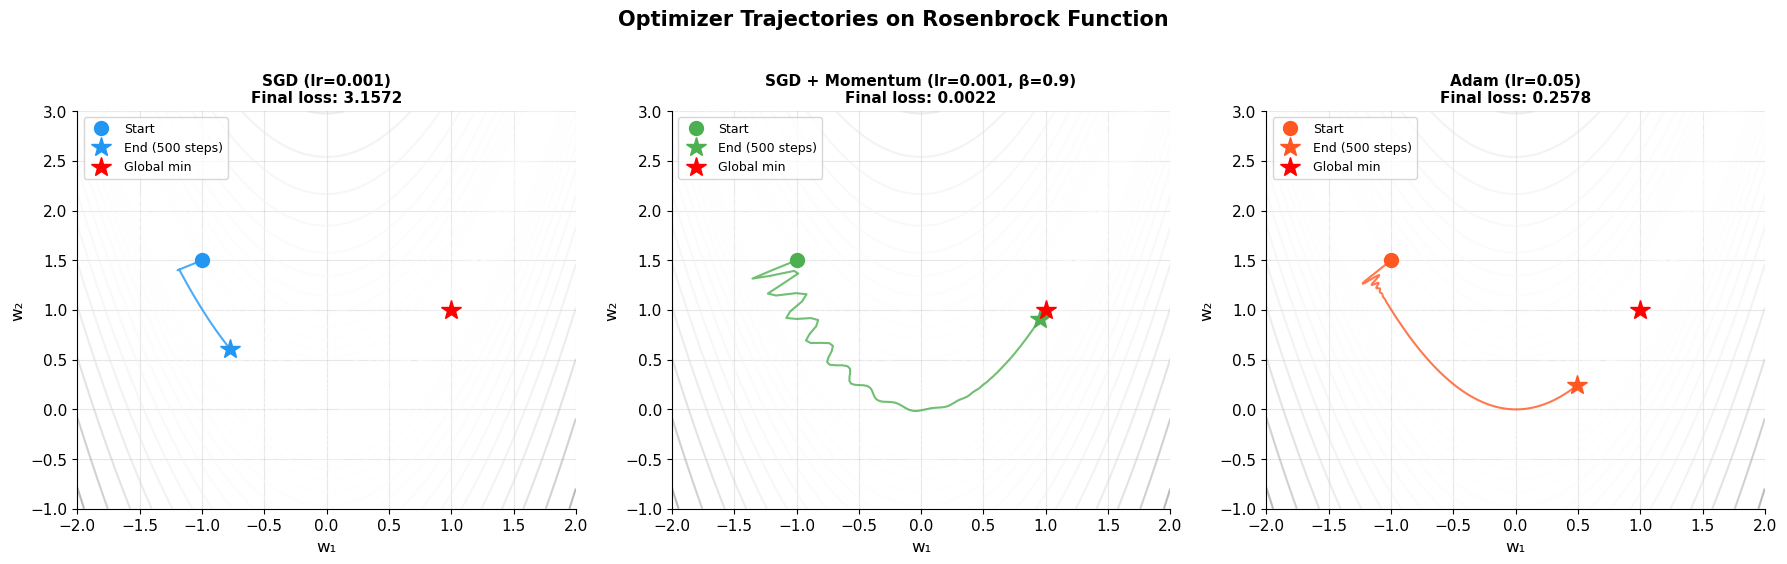

In [9]:
# Optimizer Comparison — Animated Trajectories on 2D Loss Surface
def rosenbrock(w):
    """Rosenbrock function: f(x,y) = (1-x)^2 + 100(y-x^2)^2"""
    return (1 - w[0])**2 + 100 * (w[1] - w[0]**2)**2

def rosenbrock_grad(w):
    dx = -2*(1-w[0]) + 100*2*(w[1]-w[0]**2)*(-2*w[0])
    dy = 100*2*(w[1]-w[0]**2)
    return np.array([dx, dy])

# Implement optimizers from scratch
def optimize_sgd(grad_fn, w0, lr, steps):
    w = w0.copy()
    path = [w.copy()]
    for _ in range(steps):
        g = grad_fn(w)
        w = w - lr * g
        path.append(w.copy())
    return np.array(path)

def optimize_momentum(grad_fn, w0, lr, beta, steps):
    w = w0.copy()
    v = np.zeros_like(w)
    path = [w.copy()]
    for _ in range(steps):
        g = grad_fn(w)
        v = beta * v + g
        w = w - lr * v
        path.append(w.copy())
    return np.array(path)

def optimize_adam(grad_fn, w0, lr, beta1, beta2, eps, steps):
    w = w0.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path = [w.copy()]
    for t in range(1, steps + 1):
        g = grad_fn(w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(w.copy())
    return np.array(path)

# Run optimizers
w0 = np.array([-1.0, 1.5])
steps = 500

path_sgd = optimize_sgd(rosenbrock_grad, w0, lr=0.001, steps=steps)
path_momentum = optimize_momentum(rosenbrock_grad, w0, lr=0.001, beta=0.9, steps=steps)
path_adam = optimize_adam(rosenbrock_grad, w0, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8, steps=steps)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

x_range = np.linspace(-2, 2, 300)
y_range = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(x_range, y_range)
Z = (1-X)**2 + 100*(Y - X**2)**2

for ax, path, name, color in zip(axes,
    [path_sgd, path_momentum, path_adam],
    ['SGD (lr=0.001)', 'SGD + Momentum (lr=0.001, β=0.9)', 'Adam (lr=0.05)'],
    [COLORS[0], COLORS[2], COLORS[1]]):
    
    ax.contour(X, Y, Z, levels=np.logspace(-0.5, 3.5, 30), cmap='Greys', alpha=0.4)
    ax.plot(path[:, 0], path[:, 1], '-', color=color, linewidth=1.5, alpha=0.8)
    ax.plot(path[0, 0], path[0, 1], 'o', color=color, markersize=10, label='Start')
    ax.plot(path[-1, 0], path[-1, 1], '*', color=color, markersize=15, label=f'End ({steps} steps)')
    ax.plot(1, 1, 'r*', markersize=15, zorder=10, label='Global min')
    
    final_loss = rosenbrock(path[-1])
    ax.set_title(f'{name}\nFinal loss: {final_loss:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(-2, 2); ax.set_ylim(-1, 3)

plt.suptitle('Optimizer Trajectories on Rosenbrock Function', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3.4 Learning Rate Schedules

The learning rate doesn't have to be constant. Schedules adapt $\eta$ during training:

| Schedule | Formula | Intuition |
|----------|---------|----------|
| **Step Decay** | $\eta_t = \eta_0 \cdot \gamma^{\lfloor t/s \rfloor}$ | Drop by factor $\gamma$ every $s$ steps |
| **Cosine Annealing** | $\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})(1 + \cos(\frac{t\pi}{T}))$ | Smooth decay to near-zero |
| **Warmup + Decay** | Linear increase then cosine decay | Stabilize early training, then fine-tune |
| **Cyclical** | Oscillate between $\eta_{min}$ and $\eta_{max}$ | Escape local minima periodically |
| **1/√t Decay** | $\eta_t = \eta_0 / \sqrt{t}$ | Theory-optimal for convex problems |

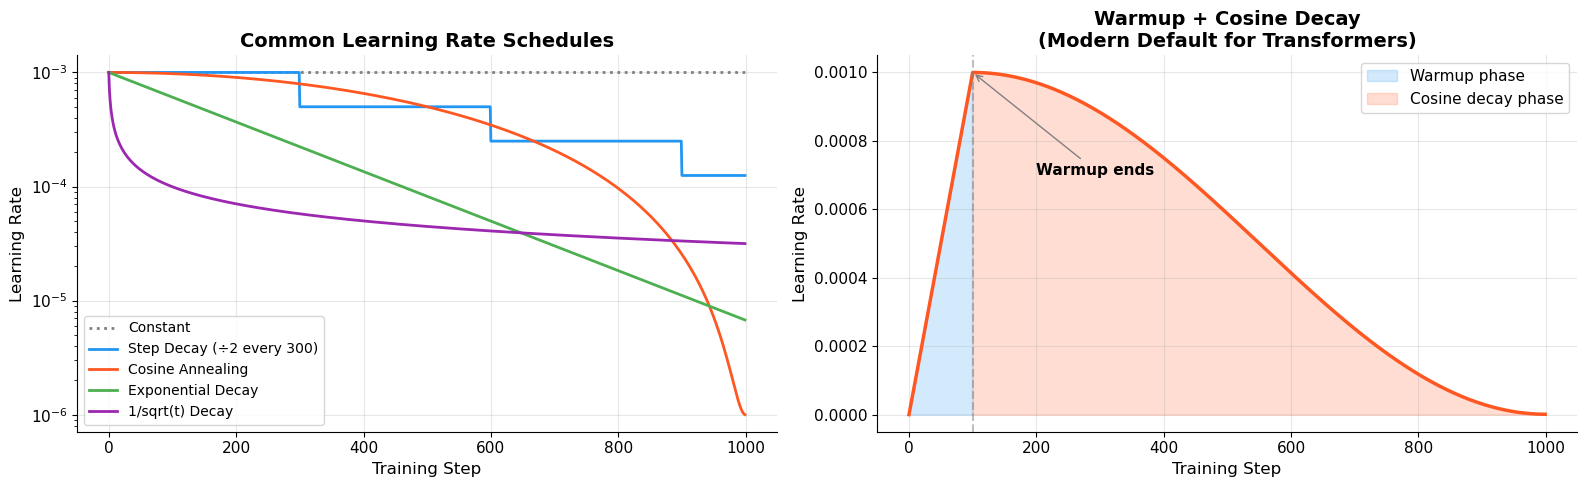

Modern best practices:
  1. Start with LINEAR WARMUP to stabilize early gradients
  2. Then COSINE DECAY to fine-tune in later stages
  3. Used in: GPT, BERT, ViT, LLaMA, and most modern architectures


In [10]:
# Learning Rate Schedules — Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

T = 1000  # Total steps
t = np.arange(T)
eta_0 = 0.001
eta_min = 1e-6

# --- Left: Common schedules ---
ax = axes[0]

# Constant
ax.plot(t, np.ones(T) * eta_0, linewidth=2, color='gray', label='Constant', linestyle=':')

# Step decay
step_lr = eta_0 * (0.5 ** (t // 300))
ax.plot(t, step_lr, linewidth=2, color=COLORS[0], label='Step Decay (÷2 every 300)')

# Cosine annealing
cosine_lr = eta_min + 0.5 * (eta_0 - eta_min) * (1 + np.cos(np.pi * t / T))
ax.plot(t, cosine_lr, linewidth=2, color=COLORS[1], label='Cosine Annealing')

# Exponential decay
exp_lr = eta_0 * np.exp(-0.005 * t)
ax.plot(t, exp_lr, linewidth=2, color=COLORS[2], label='Exponential Decay')

# 1/sqrt(t)
inv_sqrt_lr = eta_0 / np.sqrt(t + 1)
ax.plot(t, inv_sqrt_lr, linewidth=2, color=COLORS[3], label='1/sqrt(t) Decay')

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Common Learning Rate Schedules', fontweight='bold')
ax.legend(fontsize=10)
ax.set_yscale('log')

# --- Right: Warmup + Cosine (the modern default) ---
ax = axes[1]
warmup_steps = 100
total_steps = 1000

warmup_cosine = np.zeros(total_steps)
for i in range(total_steps):
    if i < warmup_steps:
        warmup_cosine[i] = eta_0 * (i / warmup_steps)  # Linear warmup
    else:
        progress = (i - warmup_steps) / (total_steps - warmup_steps)
        warmup_cosine[i] = eta_min + 0.5 * (eta_0 - eta_min) * (1 + np.cos(np.pi * progress))

ax.plot(t, warmup_cosine, linewidth=2.5, color=COLORS[1])
ax.fill_between(t[:warmup_steps], 0, warmup_cosine[:warmup_steps],
                alpha=0.2, color=COLORS[0], label='Warmup phase')
ax.fill_between(t[warmup_steps:], 0, warmup_cosine[warmup_steps:],
                alpha=0.2, color=COLORS[1], label='Cosine decay phase')

ax.axvline(warmup_steps, color='gray', linestyle='--', alpha=0.5)
ax.annotate('Warmup ends', xy=(warmup_steps, eta_0), xytext=(200, eta_0*0.7),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11, fontweight='bold')

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Warmup + Cosine Decay\n(Modern Default for Transformers)', fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print('Modern best practices:')
print('  1. Start with LINEAR WARMUP to stabilize early gradients')
print('  2. Then COSINE DECAY to fine-tune in later stages')
print('  3. Used in: GPT, BERT, ViT, LLaMA, and most modern architectures')

---
# 4. 🧮 Maximum Likelihood & MAP Estimation

Where do loss functions come from? They're not arbitrary — they're derived from **probabilistic assumptions** about the data. This section connects probability theory to optimization.

---

## 4.1 Maximum Likelihood Estimation (MLE)

**Core idea:** Find the parameters $\theta$ that maximize the probability of observing the training data.

$$\hat{\theta}_{MLE} = \arg\max_{\theta} P(D | \theta) = \arg\max_{\theta} \prod_{i=1}^{n} P(x_i | \theta)$$

In practice, we maximize the **log-likelihood** (easier to differentiate, avoids numerical underflow):

$$\hat{\theta}_{MLE} = \arg\max_{\theta} \sum_{i=1}^{n} \log P(x_i | \theta)$$

Equivalently, we **minimize the negative log-likelihood (NLL)**:

$$\hat{\theta}_{MLE} = \arg\min_{\theta} -\sum_{i=1}^{n} \log P(x_i | \theta)$$

> **This is how we get our loss functions!**

## 4.2 Deriving Loss Functions from MLE

### MSE from Gaussian Noise
Assume $y = f_\theta(x) + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma^2)$:

$$P(y | x, \theta) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(y - f_\theta(x))^2}{2\sigma^2}\right)$$

$$\log P(y|x,\theta) = -\frac{(y - f_\theta(x))^2}{2\sigma^2} - \log(\sigma\sqrt{2\pi})$$

Maximizing this over $\theta$ is equivalent to minimizing:

$$\boxed{\mathcal{L}_{MSE} = \sum_i (y_i - f_\theta(x_i))^2}$$

### Binary Cross-Entropy from Bernoulli
Assume $y \sim \text{Bernoulli}(\hat{y})$ where $\hat{y} = \sigma(f_\theta(x))$:

$$P(y|x,\theta) = \hat{y}^y (1-\hat{y})^{1-y}$$

$$\log P(y|x,\theta) = y \log \hat{y} + (1-y) \log(1-\hat{y})$$

Negating gives:

$$\boxed{\mathcal{L}_{BCE} = -[y \log \hat{y} + (1-y) \log(1-\hat{y})]}$$

### Categorical Cross-Entropy from Categorical Distribution
For $K$ classes with one-hot label $\mathbf{y}$:

$$P(\mathbf{y}|x,\theta) = \prod_{k=1}^K \hat{y}_k^{y_k}$$

$$\boxed{\mathcal{L}_{CE} = -\sum_{k=1}^K y_k \log \hat{y}_k}$$

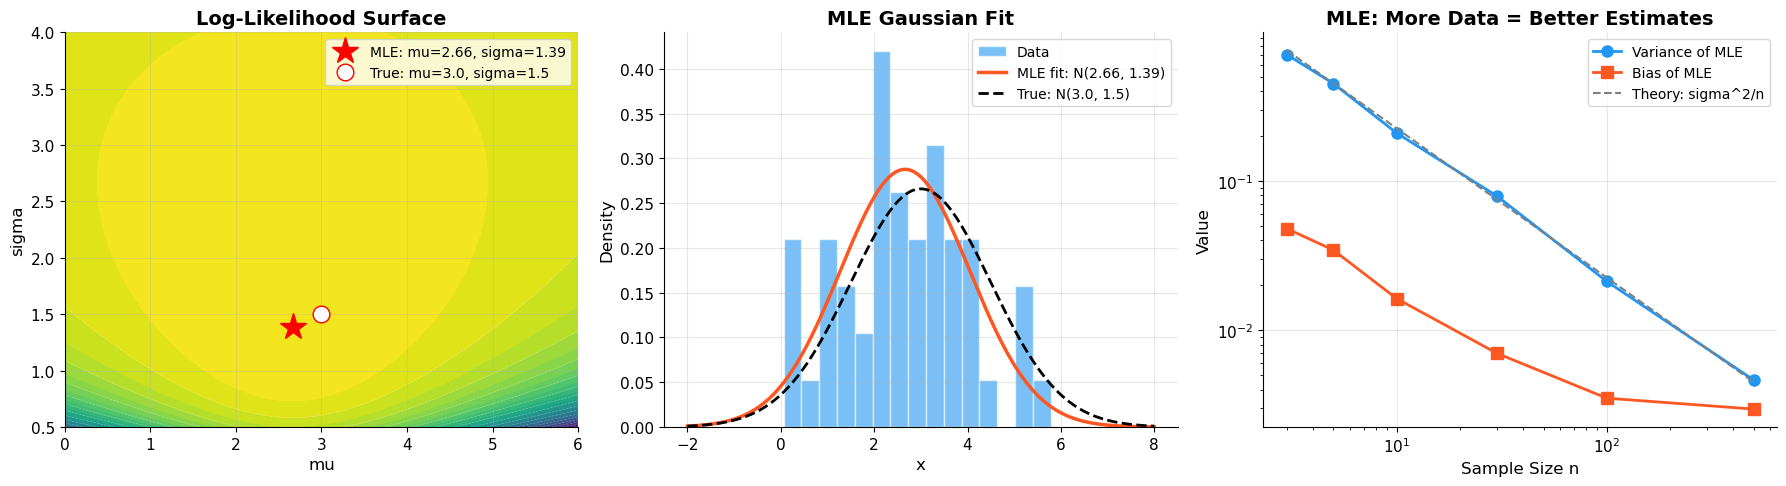

In [11]:
# MLE — Fitting a Gaussian to Data
np.random.seed(42)

# Generate data from a true Gaussian
true_mu, true_sigma = 3.0, 1.5
data = np.random.normal(true_mu, true_sigma, 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: Log-likelihood surface ---
ax = axes[0]
mu_range = np.linspace(0, 6, 200)
sigma_range = np.linspace(0.5, 4, 200)
MU, SIGMA = np.meshgrid(mu_range, sigma_range)

# Compute log-likelihood for each (mu, sigma)
LL = np.zeros_like(MU)
for i in range(len(sigma_range)):
    for j in range(len(mu_range)):
        LL[i, j] = np.sum(stats.norm.logpdf(data, MU[i, j], SIGMA[i, j]))

ax.contourf(MU, SIGMA, LL, levels=30, cmap='viridis')
ax.contour(MU, SIGMA, LL, levels=15, colors='white', alpha=0.3, linewidths=0.5)

# MLE estimates
mle_mu = np.mean(data)
mle_sigma = np.std(data)  # MLE uses n, not n-1

ax.plot(mle_mu, mle_sigma, 'r*', markersize=20, label=f'MLE: mu={mle_mu:.2f}, sigma={mle_sigma:.2f}')
ax.plot(true_mu, true_sigma, 'wo', markersize=12, markeredgecolor='red', linewidth=2,
        label=f'True: mu={true_mu}, sigma={true_sigma}')
ax.set_xlabel('mu', fontsize=12)
ax.set_ylabel('sigma', fontsize=12)
ax.set_title('Log-Likelihood Surface', fontweight='bold')
ax.legend(fontsize=10)

# --- Middle: MLE fit vs data ---
ax = axes[1]
ax.hist(data, bins=15, density=True, alpha=0.6, color=COLORS[0], edgecolor='white', label='Data')
x_fit = np.linspace(-2, 8, 200)
ax.plot(x_fit, stats.norm.pdf(x_fit, mle_mu, mle_sigma), linewidth=2.5, color=COLORS[1],
        label=f'MLE fit: N({mle_mu:.2f}, {mle_sigma:.2f})')
ax.plot(x_fit, stats.norm.pdf(x_fit, true_mu, true_sigma), linewidth=2, color='black',
        linestyle='--', label=f'True: N({true_mu}, {true_sigma})')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('MLE Gaussian Fit', fontweight='bold')
ax.legend(fontsize=10)

# --- Right: MLE vs MAP comparison ---
ax = axes[2]

# MLE can overfit with small data — show this
sample_sizes = [3, 5, 10, 30, 100, 500]
n_trials = 1000
mle_bias = []
mle_variance = []

for n in sample_sizes:
    estimates = [np.mean(np.random.normal(true_mu, true_sigma, n)) for _ in range(n_trials)]
    mle_bias.append(abs(np.mean(estimates) - true_mu))
    mle_variance.append(np.var(estimates))

ax.plot(sample_sizes, mle_variance, 'o-', linewidth=2, color=COLORS[0], markersize=8, label='Variance of MLE')
ax.plot(sample_sizes, mle_bias, 's-', linewidth=2, color=COLORS[1], markersize=8, label='Bias of MLE')

# Theoretical variance: sigma^2/n
theoretical_var = [true_sigma**2 / n for n in sample_sizes]
ax.plot(sample_sizes, theoretical_var, '--', color='gray', linewidth=1.5, label='Theory: sigma^2/n')

ax.set_xlabel('Sample Size n', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('MLE: More Data = Better Estimates', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 4.3 Maximum A Posteriori (MAP) Estimation

MAP adds a **prior** $P(\theta)$ to MLE:

$$\hat{\theta}_{MAP} = \arg\max_{\theta} P(\theta | D) = \arg\max_{\theta} \underbrace{P(D|\theta)}_{\text{likelihood}} \cdot \underbrace{P(\theta)}_{\text{prior}}$$

Taking the log:

$$\hat{\theta}_{MAP} = \arg\min_{\theta} \underbrace{-\log P(D|\theta)}_{\text{NLL (data fit)}} \underbrace{- \log P(\theta)}_{\text{regularization!}}$$

### The Bridge: Priors = Regularization

| Prior | $-\log P(\theta)$ | Regularization |
|-------|----------------|---------------|
| $\theta \sim \mathcal{N}(0, \frac{1}{2\lambda})$ | $\lambda \|\theta\|_2^2 + \text{const}$ | **L2 (Ridge / Weight Decay)** |
| $\theta \sim \text{Laplace}(0, \frac{1}{\lambda})$ | $\lambda \|\theta\|_1 + \text{const}$ | **L1 (Lasso)** |
| $\theta \sim \text{Uniform}$ (improper) | $\text{const}$ | **No regularization (= MLE)** |

$$\boxed{\text{MAP with Gaussian prior} = \text{MLE with L2 regularization (Ridge)}}$$

$$\boxed{\text{MAP with Laplace prior} = \text{MLE with L1 regularization (Lasso)}}$$

This is one of the most elegant connections in all of ML — **regularization is just Bayesian inference with informative priors!**

AttributeError: module 'numpy' has no attribute 'trapz'

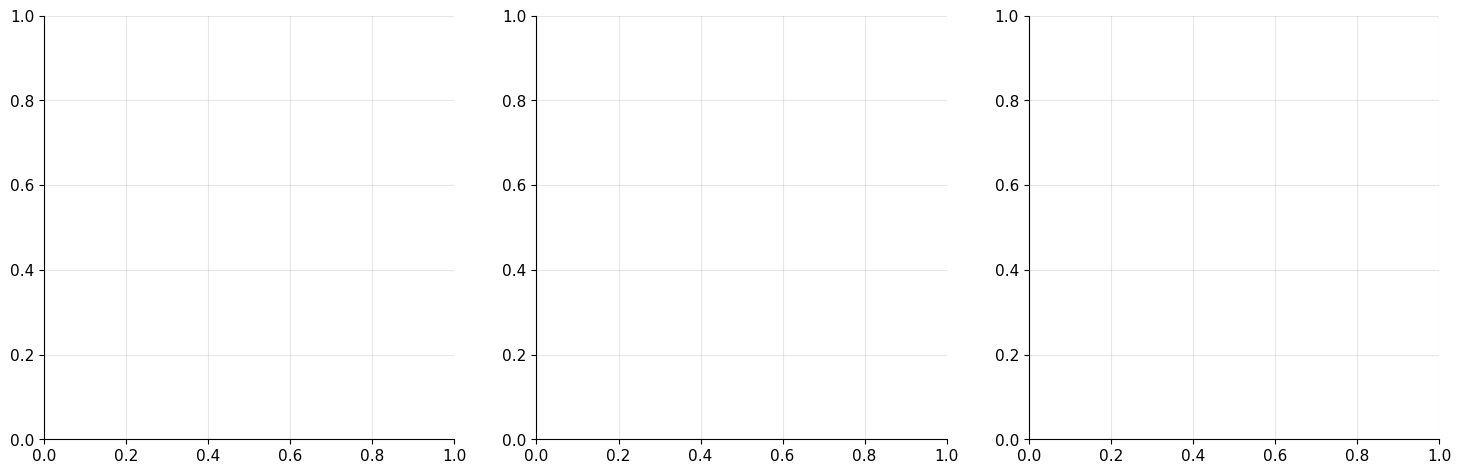

In [12]:
# MAP vs MLE — Visualizing the effect of priors
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Generate small dataset (where prior matters most)
true_theta = 3.0
n_data = 5
data_small = np.random.normal(true_theta, 2.0, n_data)

theta_range = np.linspace(-4, 8, 500)

# --- Left: Likelihood × Prior = Posterior ---
ax = axes[0]

# Likelihood: product of Gaussians
log_likelihood = np.sum([stats.norm.logpdf(x, theta_range, 2.0) for x in data_small], axis=0)
likelihood = np.exp(log_likelihood - log_likelihood.max())  # Normalize for plotting

# Prior: Gaussian centered at 0
prior_sigma = 2.0
prior = stats.norm.pdf(theta_range, 0, prior_sigma)

# Posterior proportional to likelihood * prior
posterior = likelihood * prior
posterior = posterior / np.trapz(posterior, theta_range)  # Normalize
likelihood_norm = likelihood / np.trapz(likelihood, theta_range)

ax.plot(theta_range, likelihood_norm, linewidth=2.5, color=COLORS[0], label='Likelihood P(D|θ)')
ax.plot(theta_range, prior / np.trapz(prior, theta_range), linewidth=2.5, color=COLORS[2],
        label=f'Prior N(0, {prior_sigma}²)', linestyle='--')
ax.plot(theta_range, posterior, linewidth=2.5, color=COLORS[1], label='Posterior P(θ|D)')
ax.fill_between(theta_range, posterior, alpha=0.15, color=COLORS[1])

# Mark MLE and MAP
mle_est = theta_range[np.argmax(likelihood)]
map_est = theta_range[np.argmax(posterior)]
ax.axvline(mle_est, color=COLORS[0], linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(map_est, color=COLORS[1], linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(true_theta, color='black', linestyle=':', linewidth=1.5, alpha=0.5)

ax.annotate(f'MLE={mle_est:.1f}', (mle_est, 0.02), fontsize=10, color=COLORS[0], fontweight='bold')
ax.annotate(f'MAP={map_est:.1f}', (map_est, 0.05), fontsize=10, color=COLORS[1], fontweight='bold')

ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Likelihood × Prior = Posterior\n(Small Data: n=5, Prior Matters!)', fontweight='bold')
ax.legend(fontsize=10)

# --- Middle: Prior strength effect ---
ax = axes[1]

prior_sigmas = [0.5, 1.0, 2.0, 5.0, 50.0]
map_estimates = []

for ps in prior_sigmas:
    prior_curr = stats.norm.pdf(theta_range, 0, ps)
    post_curr = likelihood * prior_curr
    map_est_curr = theta_range[np.argmax(post_curr)]
    map_estimates.append(map_est_curr)

ax.plot(prior_sigmas, map_estimates, 'o-', linewidth=2.5, color=COLORS[1], markersize=10, label='MAP estimate')
ax.axhline(np.mean(data_small), color=COLORS[0], linestyle='--', linewidth=1.5, label=f'MLE = {np.mean(data_small):.2f}')
ax.axhline(0, color=COLORS[2], linestyle=':', linewidth=1.5, label='Prior mean = 0')
ax.axhline(true_theta, color='black', linestyle=':', linewidth=1, alpha=0.5, label=f'True θ = {true_theta}')

ax.set_xlabel('Prior σ (weaker prior →)', fontsize=12)
ax.set_ylabel('MAP Estimate', fontsize=12)
ax.set_title('MAP Interpolates Between Prior & MLE\nWeak prior → MAP ≈ MLE', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xscale('log')

# --- Right: L2 regularization = Gaussian prior ---
ax = axes[2]

# Show the equivalence geometrically
theta_1d = np.linspace(-5, 8, 500)

# NLL (data loss)
nll = -np.sum([stats.norm.logpdf(x, theta_1d, 2.0) for x in data_small], axis=0)

# L2 penalty for different lambda
for i, lam in enumerate([0, 0.5, 2.0, 5.0]):
    total_loss = nll + lam * theta_1d**2
    total_loss_norm = total_loss - total_loss.min()  # Shift for visibility
    label = f'NLL + {lam}·θ²' if lam > 0 else 'NLL only (MLE)'
    style = '-' if lam > 0 else '--'
    ax.plot(theta_1d, total_loss_norm, linewidth=2, color=COLORS[i], label=label, linestyle=style)
    # Mark minimum
    min_idx = np.argmin(total_loss)
    ax.plot(theta_1d[min_idx], total_loss_norm[min_idx], 'v', color=COLORS[i], markersize=10)

ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('Total Loss', fontsize=12)
ax.set_title('L2 Regularization Pulls Minimum\nToward Zero (= Gaussian Prior)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 20)

plt.tight_layout()
plt.show()

print('Key Takeaway:')
print('  MLE = Just fit the data (can overfit with small n)')
print('  MAP = Fit the data + incorporate prior beliefs (= regularization)')
print('  Strong prior + little data: MAP is pulled toward prior')
print('  Weak prior + lots of data: MAP converges to MLE')

---
# 5. 🎰 Sampling Methods

Many quantities in ML involve **intractable integrals** (expectations over complex distributions). Sampling methods let us **approximate** these integrals using random samples.

---

## 5.1 Monte Carlo Estimation

**Core idea:** Approximate an expectation with a sample average.

$$E_{x \sim P}[f(x)] = \int f(x) P(x) dx \approx \frac{1}{N} \sum_{i=1}^{N} f(x_i), \quad x_i \sim P$$

**Properties:**
- Unbiased estimator
- Variance decreases as $O(1/N)$ — independent of dimensionality!
- Error: $\text{Std Error} = \sigma / \sqrt{N}$

## 5.2 Importance Sampling

What if we can't sample from $P$ directly? Use a **proposal distribution** $Q$:

$$E_{x \sim P}[f(x)] = \int f(x) \frac{P(x)}{Q(x)} Q(x) dx = E_{x \sim Q}\left[f(x) \frac{P(x)}{Q(x)}\right]$$

$$\approx \frac{1}{N} \sum_{i=1}^{N} f(x_i) \cdot w_i, \quad x_i \sim Q, \quad w_i = \frac{P(x_i)}{Q(x_i)}$$

The ratios $w_i = P(x_i)/Q(x_i)$ are called **importance weights**.

> **ML Usage:** Off-policy reinforcement learning (PPO), rare event estimation, variational inference.

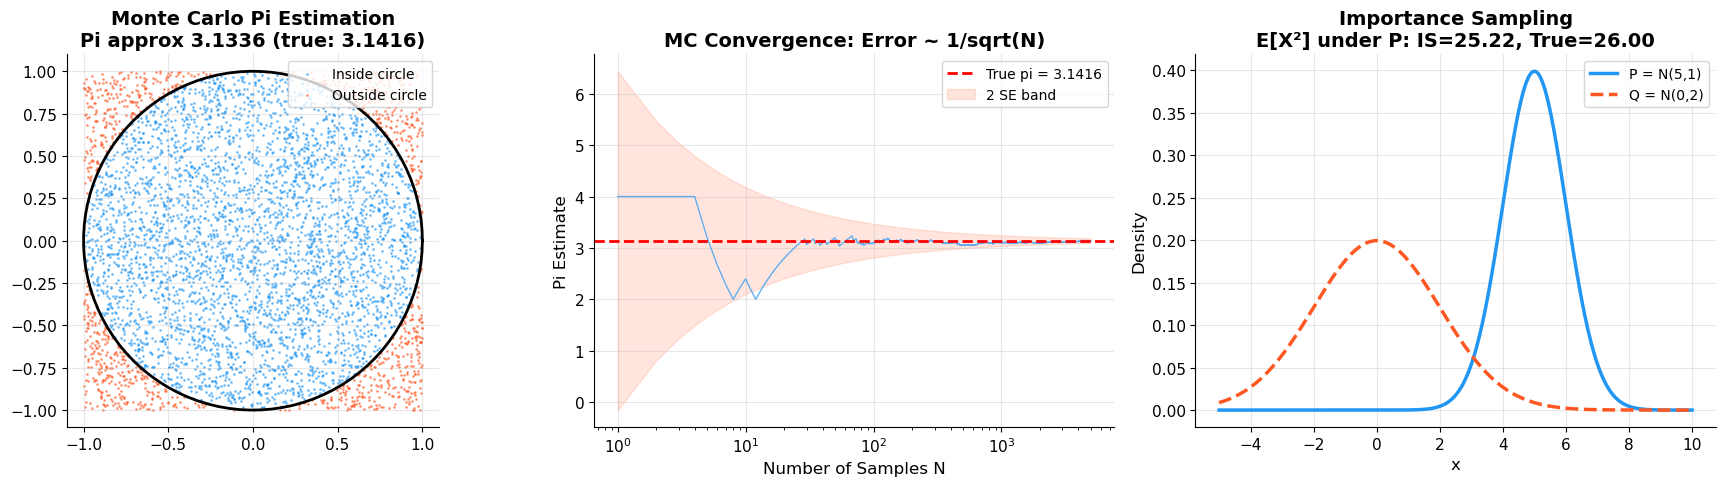

In [13]:
# Monte Carlo Estimation — Estimating Pi and Convergence
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: Estimating Pi via Monte Carlo ---
ax = axes[0]
N = 5000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)
inside = x**2 + y**2 <= 1

ax.scatter(x[inside], y[inside], s=1, alpha=0.5, color=COLORS[0], label='Inside circle')
ax.scatter(x[~inside], y[~inside], s=1, alpha=0.5, color=COLORS[1], label='Outside circle')

theta_circle = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta_circle), np.sin(theta_circle), 'k-', linewidth=2)

pi_estimate = 4 * np.mean(inside)
ax.set_title(f'Monte Carlo Pi Estimation\nPi approx {pi_estimate:.4f} (true: {np.pi:.4f})', fontweight='bold')
ax.set_aspect('equal')
ax.legend(fontsize=10)

# --- Middle: Convergence of MC estimate ---
ax = axes[1]
ns = np.arange(1, N+1)
cumulative_pi = 4 * np.cumsum(inside) / ns

ax.plot(ns, cumulative_pi, linewidth=1, color=COLORS[0], alpha=0.7)
ax.axhline(np.pi, color='red', linestyle='--', linewidth=2, label=f'True pi = {np.pi:.4f}')

# Standard error bands
se = 4 * np.sqrt(np.mean(inside) * (1-np.mean(inside)) / ns)
ax.fill_between(ns, np.pi - 2*se, np.pi + 2*se, alpha=0.15, color=COLORS[1], label='2 SE band')

ax.set_xlabel('Number of Samples N', fontsize=12)
ax.set_ylabel('Pi Estimate', fontsize=12)
ax.set_title('MC Convergence: Error ~ 1/sqrt(N)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xscale('log')

# --- Right: Importance Sampling ---
ax = axes[2]

# Task: Estimate E[f(x)] where f(x) = x^2, x ~ N(5, 1)
# But we can only easily sample from Q = N(0, 2)

# Target distribution P
P_mean, P_std = 5, 1
# Proposal distribution Q
Q_mean, Q_std = 0, 2

x_range = np.linspace(-5, 10, 500)
ax.plot(x_range, stats.norm.pdf(x_range, P_mean, P_std), linewidth=2.5,
        color=COLORS[0], label=f'P = N({P_mean},{P_std})')
ax.plot(x_range, stats.norm.pdf(x_range, Q_mean, Q_std), linewidth=2.5,
        color=COLORS[1], label=f'Q = N({Q_mean},{Q_std})', linestyle='--')

# Importance sampling
n_samples = 10000
samples_q = np.random.normal(Q_mean, Q_std, n_samples)
importance_weights = stats.norm.pdf(samples_q, P_mean, P_std) / stats.norm.pdf(samples_q, Q_mean, Q_std)

f_x = samples_q ** 2
is_estimate = np.mean(f_x * importance_weights)
true_value = P_mean**2 + P_std**2  # E[X^2] = mu^2 + sigma^2

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Importance Sampling\nE[X²] under P: IS={is_estimate:.2f}, True={true_value:.2f}', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 5.3 Markov Chain Monte Carlo (MCMC)

When we can't sample from $P$ directly and importance sampling has high variance, MCMC constructs a **Markov chain** whose stationary distribution is $P$.

### Metropolis-Hastings Algorithm

1. Start at some $x_0$
2. Propose $x' \sim Q(x' | x_t)$ (e.g., $x' = x_t + \epsilon$, $\epsilon \sim \mathcal{N}(0, \sigma^2)$)
3. Accept with probability $\alpha = \min\left(1, \frac{P(x') Q(x_t | x')}{P(x_t) Q(x' | x_t)}\right)$
4. If symmetric proposal ($Q(x'|x) = Q(x|x')$): $\alpha = \min\left(1, \frac{P(x')}{P(x_t)}\right)$
5. Set $x_{t+1} = x'$ if accepted, else $x_{t+1} = x_t$

**Key properties:**
- After a **burn-in** period, samples approximate the target distribution
- Consecutive samples are correlated (use thinning)
- Works even when $P$ is known only up to a constant ($P \propto \tilde{P}$, we only need ratios!)

> **ML Usage:** Bayesian inference, probabilistic programming (Stan, PyMC), sampling from energy-based models.

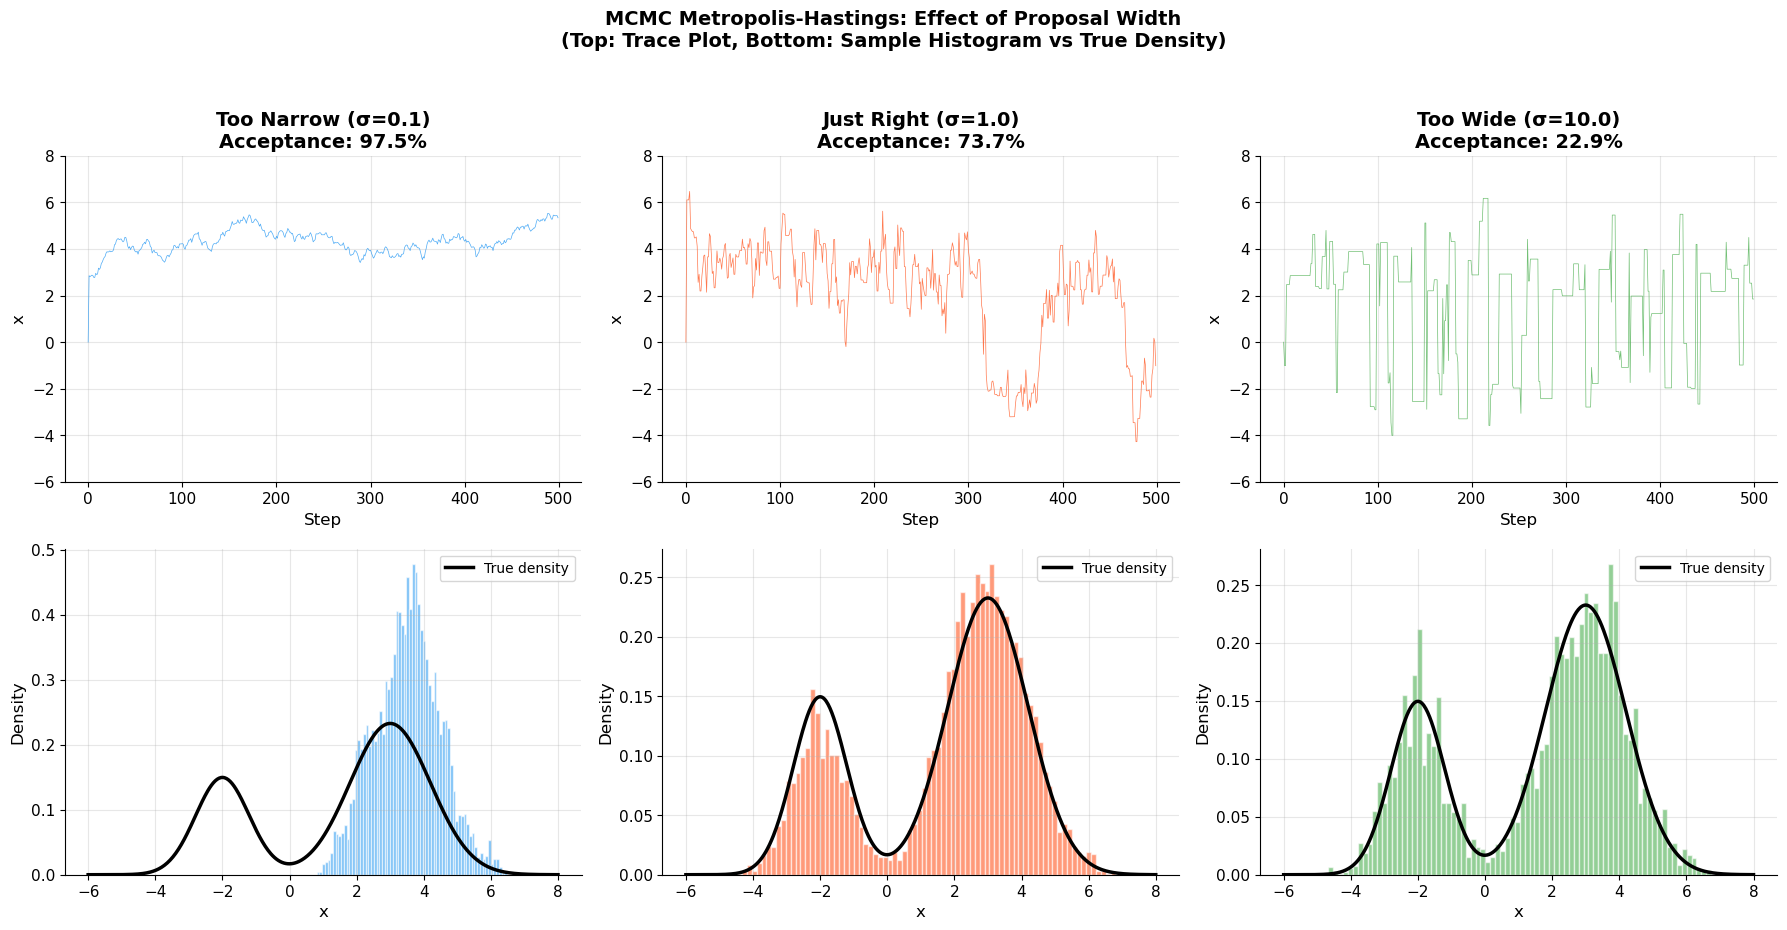

Tuning insight:
  Too narrow proposal: High acceptance but slow exploration (correlated samples)
  Too wide proposal: Many rejections (wasted computation)
  Optimal: ~20-50% acceptance rate (Roberts et al., 1997)


In [14]:
# MCMC — Metropolis-Hastings Sampling from a Complex Distribution
np.random.seed(42)

# Target: bimodal distribution (mixture of Gaussians)
def target_log_prob(x):
    """Log of unnormalized target distribution (bimodal)"""
    return np.logaddexp(
        np.log(0.3) + stats.norm.logpdf(x, -2, 0.8),
        np.log(0.7) + stats.norm.logpdf(x, 3, 1.2)
    )

def metropolis_hastings(log_prob, x0, proposal_std, n_samples, burn_in=500):
    samples = [x0]
    accepted = 0
    x = x0
    for i in range(n_samples + burn_in):
        # Propose
        x_proposed = x + np.random.normal(0, proposal_std)
        # Accept/reject
        log_alpha = log_prob(x_proposed) - log_prob(x)
        if np.log(np.random.uniform()) < log_alpha:
            x = x_proposed
            if i >= burn_in:
                accepted += 1
        if i >= burn_in:
            samples.append(x)
    acceptance_rate = accepted / n_samples
    return np.array(samples), acceptance_rate

# Run MCMC with different proposal widths
n_samples = 10000
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

proposal_stds = [0.1, 1.0, 10.0]
titles = ['Too Narrow (σ=0.1)', 'Just Right (σ=1.0)', 'Too Wide (σ=10.0)']

x_true = np.linspace(-6, 8, 500)
true_density = 0.3 * stats.norm.pdf(x_true, -2, 0.8) + 0.7 * stats.norm.pdf(x_true, 3, 1.2)

for col, (prop_std, title) in enumerate(zip(proposal_stds, titles)):
    samples, acc_rate = metropolis_hastings(target_log_prob, 0, prop_std, n_samples)
    
    # Top row: trace plot (first 500 samples)
    ax = axes[0][col]
    ax.plot(samples[:500], linewidth=0.5, color=COLORS[col], alpha=0.8)
    ax.set_xlabel('Step')
    ax.set_ylabel('x')
    ax.set_title(f'{title}\nAcceptance: {acc_rate:.1%}', fontweight='bold')
    ax.set_ylim(-6, 8)
    
    # Bottom row: histogram vs true
    ax = axes[1][col]
    ax.hist(samples, bins=80, density=True, alpha=0.6, color=COLORS[col], edgecolor='white')
    ax.plot(x_true, true_density, 'k-', linewidth=2.5, label='True density')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend(fontsize=10)

plt.suptitle('MCMC Metropolis-Hastings: Effect of Proposal Width\n'
             '(Top: Trace Plot, Bottom: Sample Histogram vs True Density)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Tuning insight:')
print('  Too narrow proposal: High acceptance but slow exploration (correlated samples)')
print('  Too wide proposal: Many rejections (wasted computation)')
print('  Optimal: ~20-50% acceptance rate (Roberts et al., 1997)')

## 5.4 The Reparameterization Trick

A crucial technique for training VAEs and any model that needs to **backpropagate through random sampling**.

### The Problem
If $z \sim q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$, we want:

$$\nabla_\phi E_{z \sim q_\phi}[f(z)]$$

But sampling is a non-differentiable operation — we can't backpropagate through "sample from $\mathcal{N}(\mu, \sigma^2)$".

### The Solution
Reparameterize: instead of sampling $z$ directly from $q_\phi$, express $z$ as a **deterministic function** of $\phi$ and a noise variable $\epsilon$:

$$\epsilon \sim \mathcal{N}(0, 1) \quad \text{(noise, independent of } \phi \text{)}$$
$$z = \mu_\phi(x) + \sigma_\phi(x) \cdot \epsilon \quad \text{(deterministic function of } \phi \text{)}$$

Now $z$ is differentiable w.r.t. $\phi$!

$$\frac{\partial z}{\partial \mu} = 1, \qquad \frac{\partial z}{\partial \sigma} = \epsilon$$

$$\nabla_\phi E_{z \sim q_\phi}[f(z)] = E_{\epsilon \sim \mathcal{N}(0,1)}[\nabla_\phi f(\mu_\phi + \sigma_\phi \cdot \epsilon)]$$

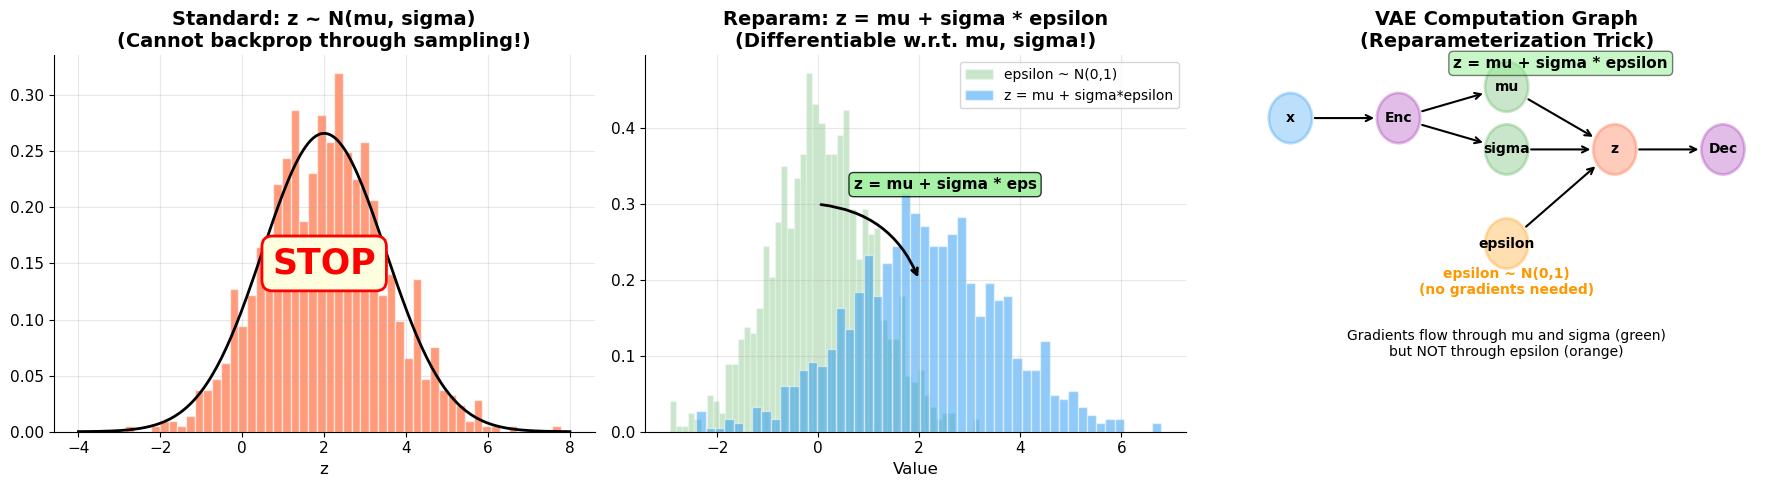

In [15]:
# Reparameterization Trick — Visual Explanation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

np.random.seed(42)

# Parameters
mu = 2.0
sigma = 1.5
n_samples = 1000

# --- Left: Standard sampling (non-differentiable) ---
ax = axes[0]
z_standard = np.random.normal(mu, sigma, n_samples)

ax.hist(z_standard, bins=50, density=True, alpha=0.6, color=COLORS[1], edgecolor='white')
x_range = np.linspace(-4, 8, 200)
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'k-', linewidth=2)

ax.set_title('Standard: z ~ N(mu, sigma)\n(Cannot backprop through sampling!)', fontweight='bold')
ax.set_xlabel('z')
ax.annotate('STOP', xy=(mu, 0.15), fontsize=25, fontweight='bold', color='red',
            ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red', linewidth=2))

# --- Middle: Reparameterized (differentiable) ---
ax = axes[1]
epsilon = np.random.normal(0, 1, n_samples)  # Fixed noise
z_reparam = mu + sigma * epsilon  # Deterministic transform

# Show the flow: epsilon -> z
# Plot epsilon distribution
ax.hist(epsilon, bins=50, density=True, alpha=0.3, color=COLORS[2], edgecolor='white', label='epsilon ~ N(0,1)')
ax.hist(z_reparam, bins=50, density=True, alpha=0.5, color=COLORS[0], edgecolor='white', label='z = mu + sigma*epsilon')

# Arrow showing transformation
ax.annotate('', xy=(mu, 0.2), xytext=(0, 0.3),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, connectionstyle='arc3,rad=-0.3'))
ax.text(0.7, 0.32, 'z = mu + sigma * eps', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

ax.set_title('Reparam: z = mu + sigma * epsilon\n(Differentiable w.r.t. mu, sigma!)', fontweight='bold')
ax.set_xlabel('Value')
ax.legend(fontsize=10)

# --- Right: Computation graph ---
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Draw computation graph
nodes = {
    'x': (1, 5), 'encoder': (3, 5), 'mu': (5, 5.5), 'sigma': (5, 4.5),
    'eps': (5, 3), 'z': (7, 4.5), 'decoder': (9, 4.5)
}

node_colors = {
    'x': COLORS[0], 'encoder': COLORS[3], 'mu': COLORS[2], 'sigma': COLORS[2],
    'eps': COLORS[4], 'z': COLORS[1], 'decoder': COLORS[3]
}

for name, (x_pos, y_pos) in nodes.items():
    ax.add_patch(plt.Circle((x_pos, y_pos), 0.4, facecolor=node_colors[name], alpha=0.3,
                            edgecolor=node_colors[name], linewidth=2))
    display = {'eps': 'epsilon', 'encoder': 'Enc', 'decoder': 'Dec'}.get(name, name)
    ax.text(x_pos, y_pos, display, ha='center', va='center', fontweight='bold', fontsize=10)

# Edges
edges = [('x', 'encoder'), ('encoder', 'mu'), ('encoder', 'sigma'),
         ('mu', 'z'), ('sigma', 'z'), ('eps', 'z'), ('z', 'decoder')]

for start, end in edges:
    sx, sy = nodes[start]
    ex, ey = nodes[end]
    dx, dy = ex - sx, ey - sy
    dist = np.sqrt(dx**2 + dy**2)
    ax.annotate('', xy=(ex - 0.4*dx/dist, ey - 0.4*dy/dist),
                xytext=(sx + 0.4*dx/dist, sy + 0.4*dy/dist),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Labels
ax.text(5, 2.2, 'epsilon ~ N(0,1)\n(no gradients needed)', ha='center', fontsize=10,
        color=COLORS[4], fontweight='bold')
ax.text(6, 5.8, 'z = mu + sigma * epsilon', ha='center', fontsize=11,
        fontweight='bold', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.text(5, 1.2, 'Gradients flow through mu and sigma (green)\nbut NOT through epsilon (orange)',
        ha='center', fontsize=10)

ax.set_title('VAE Computation Graph\n(Reparameterization Trick)', fontweight='bold')

plt.tight_layout()
plt.show()

---
# 6. 🌊 Variational Inference & VAEs

Variational Inference (VI) is a technique for **approximate Bayesian inference** — it turns the problem of computing intractable posteriors into an **optimization problem**.

---

## 6.1 The Problem: Intractable Posteriors

In many models, we want the posterior $P(z|x)$ over latent variables $z$ given observed data $x$:

$$P(z|x) = \frac{P(x|z) P(z)}{P(x)} = \frac{P(x|z) P(z)}{\int P(x|z) P(z) dz}$$

The denominator $P(x) = \int P(x|z) P(z) dz$ (the **evidence**) requires integrating over all possible $z$ — often **intractable** in high dimensions.

## 6.2 The Solution: Approximate with a Simpler Distribution

Instead of computing $P(z|x)$ exactly, **approximate** it with a simpler distribution $q_\phi(z|x)$ (e.g., a Gaussian) and optimize $\phi$ to make $q$ close to $P(z|x)$:

$$\min_\phi D_{KL}(q_\phi(z|x) \| P(z|x))$$

## 6.3 Deriving the ELBO

The KL divergence above involves $P(z|x)$ which we can't compute. But we can derive a **tractable** lower bound on $\log P(x)$:

$$\log P(x) = \underbrace{E_{z \sim q}\left[\log \frac{P(x, z)}{q(z|x)}\right]}_{\text{ELBO } \mathcal{L}(\phi)} + \underbrace{D_{KL}(q(z|x) \| P(z|x))}_{\geq 0}$$

Since $D_{KL} \geq 0$:

$$\log P(x) \geq \text{ELBO} = E_{z \sim q}[\log P(x|z)] - D_{KL}(q(z|x) \| P(z))$$

### The ELBO Decomposition

$$\boxed{\text{ELBO} = \underbrace{E_{z \sim q_\phi}[\log P_\theta(x|z)]}_{\text{Reconstruction}} - \underbrace{D_{KL}(q_\phi(z|x) \| P(z))}_{\text{Regularization}}}$$

| Term | Interpretation | Effect |
|------|---------------|--------|
| **Reconstruction** | How well can the decoder reconstruct $x$ from $z$? | Encourages accurate encoding |
| **KL Regularization** | How close is $q(z|x)$ to the prior $P(z)$? | Encourages smooth, well-organized latent space |

## 6.4 Variational Autoencoder (VAE)

A VAE uses neural networks for both:
- **Encoder** $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$ — outputs mean and variance
- **Decoder** $P_\theta(x|z)$ — generates data from latent code

Training maximizes the ELBO using the **reparameterization trick** for differentiable sampling.

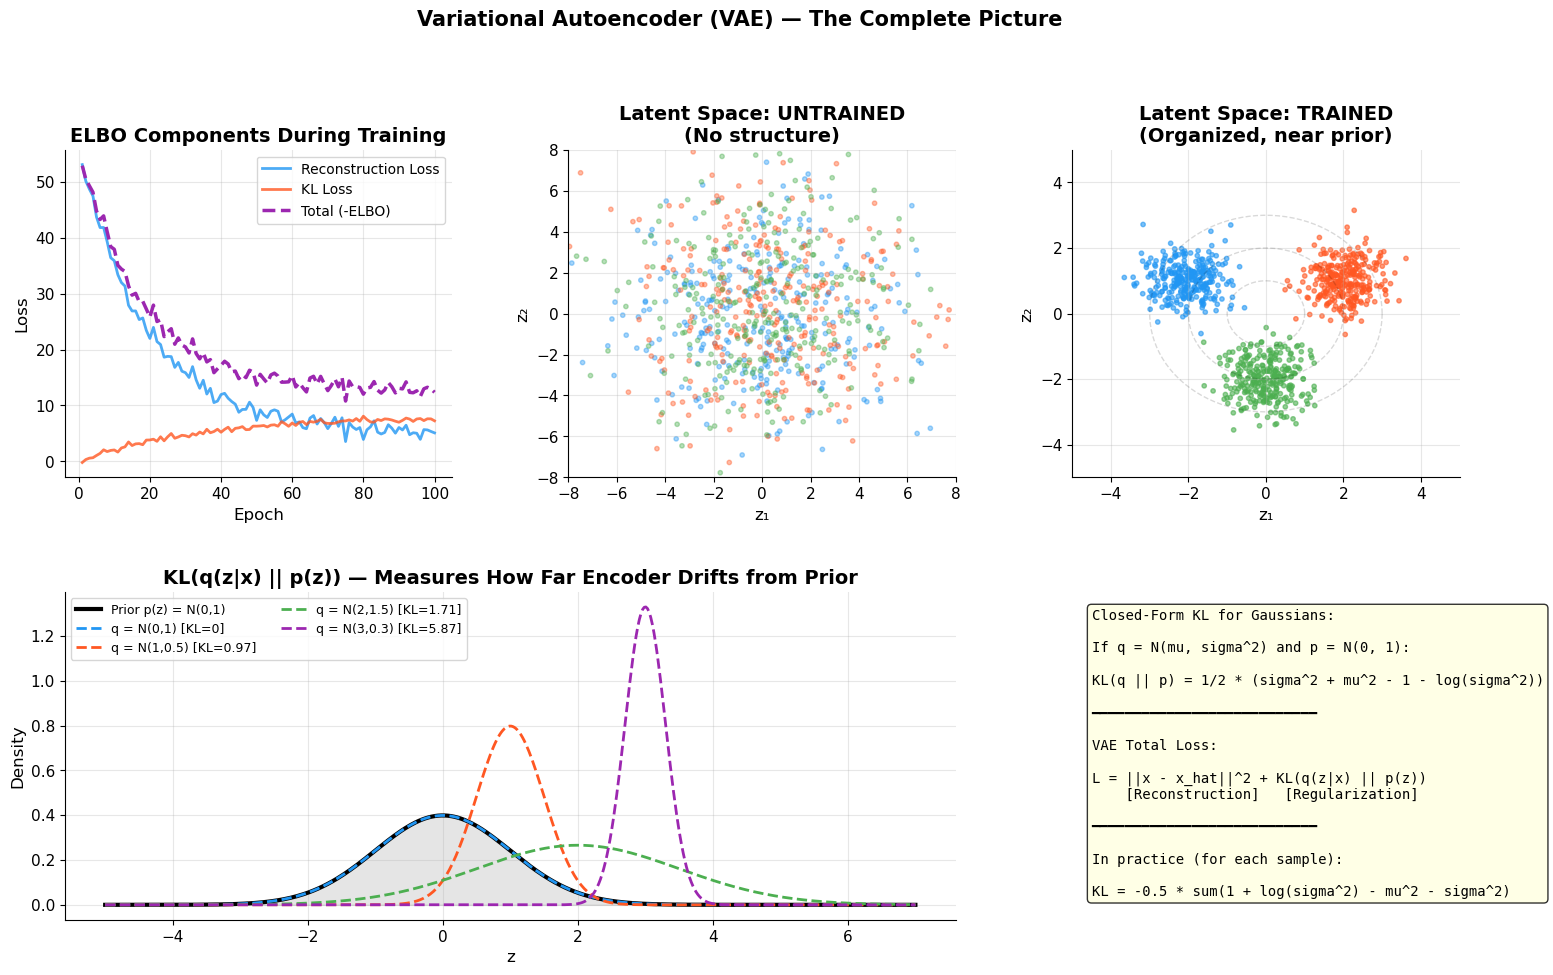

In [16]:
# ELBO & VAE — Visual Explanation
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# --- Top Left: ELBO decomposition ---
ax = fig.add_subplot(gs[0, 0])

# Simulate ELBO components during training
np.random.seed(42)
epochs = np.arange(1, 101)

# Reconstruction loss decreases
recon = 50 * np.exp(-0.05 * epochs) + 5 + np.random.randn(100) * 1
# KL loss increases then stabilizes
kl = 8 * (1 - np.exp(-0.03 * epochs)) + np.random.randn(100) * 0.3
# Total ELBO = -(recon + kl) — we plot the loss version
total = recon + kl

ax.plot(epochs, recon, linewidth=2, color=COLORS[0], label='Reconstruction Loss', alpha=0.8)
ax.plot(epochs, kl, linewidth=2, color=COLORS[1], label='KL Loss', alpha=0.8)
ax.plot(epochs, total, linewidth=2.5, color=COLORS[3], label='Total (-ELBO)', linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('ELBO Components During Training', fontweight='bold')
ax.legend(fontsize=10)

# --- Top Middle: Latent space before/after training ---
ax = fig.add_subplot(gs[0, 1])

# Simulate "before" (random, no structure)
np.random.seed(42)
n_points = 300
labels = np.repeat([0, 1, 2], n_points)
colors_points = np.array([COLORS[0], COLORS[1], COLORS[2]])[labels]

# Random scattered latent codes (untrained)
z_before = np.random.randn(3 * n_points, 2) * 3

ax.scatter(z_before[:, 0], z_before[:, 1], c=colors_points, s=10, alpha=0.4)
ax.set_title('Latent Space: UNTRAINED\n(No structure)', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_xlim(-8, 8); ax.set_ylim(-8, 8)

# --- Top Right: Latent space after training ---
ax = fig.add_subplot(gs[0, 2])

# Organized clusters (trained)
z_after = np.vstack([
    np.random.multivariate_normal([-2, 1], 0.3*np.eye(2), n_points),
    np.random.multivariate_normal([2, 1], 0.3*np.eye(2), n_points),
    np.random.multivariate_normal([0, -2], 0.3*np.eye(2), n_points),
])

ax.scatter(z_after[:, 0], z_after[:, 1], c=colors_points, s=10, alpha=0.6)

# Draw prior N(0,I)
theta_c = np.linspace(0, 2*np.pi, 100)
for r in [1, 2, 3]:
    ax.plot(r*np.cos(theta_c), r*np.sin(theta_c), 'k--', alpha=0.15, linewidth=1)

ax.set_title('Latent Space: TRAINED\n(Organized, near prior)', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)

# --- Bottom: KL divergence between q(z|x) and p(z) ---
ax = fig.add_subplot(gs[1, 0:2])

x_range = np.linspace(-5, 7, 500)

# Prior p(z) = N(0, 1)
prior = stats.norm.pdf(x_range, 0, 1)

# Different q(z|x) = N(mu, sigma^2)
qs = [
    (0, 1, 'q = N(0,1) [KL=0]'),
    (1, 0.5, 'q = N(1,0.5) [KL=0.97]'),
    (2, 1.5, 'q = N(2,1.5) [KL=1.71]'),
    (3, 0.3, 'q = N(3,0.3) [KL=5.87]'),
]

ax.plot(x_range, prior, 'k-', linewidth=3, label='Prior p(z) = N(0,1)')
ax.fill_between(x_range, prior, alpha=0.1, color='black')

for i, (mu_q, sigma_q, label) in enumerate(qs):
    q_pdf = stats.norm.pdf(x_range, mu_q, sigma_q)
    # Compute actual KL
    kl_val = 0.5 * (sigma_q**2 + mu_q**2 - 1 - np.log(sigma_q**2))
    ax.plot(x_range, q_pdf, linewidth=2, color=COLORS[i], linestyle='--',
            label=f'{label}')

ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('KL(q(z|x) || p(z)) — Measures How Far Encoder Drifts from Prior', fontweight='bold')
ax.legend(fontsize=9, ncol=2)

# --- Bottom Right: KL formula ---
ax = fig.add_subplot(gs[1, 2])
ax.axis('off')

formula_text = (
    'Closed-Form KL for Gaussians:\n\n'
    'If q = N(mu, sigma^2) and p = N(0, 1):\n\n'
    'KL(q || p) = 1/2 * (sigma^2 + mu^2 - 1 - log(sigma^2))\n\n'
    '━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n'
    'VAE Total Loss:\n\n'
    'L = ||x - x_hat||^2 + KL(q(z|x) || p(z))\n'
    '    [Reconstruction]   [Regularization]\n\n'
    '━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n'
    'In practice (for each sample):\n\n'
    'KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)'
)
ax.text(0.05, 0.95, formula_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Variational Autoencoder (VAE) — The Complete Picture',
             fontsize=15, fontweight='bold', y=1.02)
plt.show()

---
# 7. 📊 Hypothesis Testing & Statistical Significance

When comparing ML models or running experiments, we need rigorous statistical tools to distinguish **real improvements** from **random noise**.

---

## 7.1 Core Concepts

### Null Hypothesis ($H_0$) & Alternative ($H_1$)

- $H_0$: "There is **no difference** between model A and model B" (default assumption)
- $H_1$: "There **is** a difference" (what we're trying to show)

### p-value

> The probability of observing a result **at least as extreme** as what we got, **assuming $H_0$ is true**.

$$\text{p-value} = P(\text{observed or more extreme} | H_0)$$

- $p < \alpha$ (typically $\alpha = 0.05$): **Reject $H_0$** — result is "statistically significant"
- $p \geq \alpha$: **Fail to reject $H_0$** — insufficient evidence

### Type I and Type II Errors

| | $H_0$ True | $H_0$ False |
|---|-----------|------------|
| **Reject $H_0$** | Type I Error ($\alpha$) "False Positive" | Correct! (Power = $1-\beta$) |
| **Fail to Reject** | Correct! | Type II Error ($\beta$) "False Negative" |

### Confidence Intervals

A $(1-\alpha)$ confidence interval for a parameter $\theta$:

$$\hat{\theta} \pm z_{\alpha/2} \cdot \text{SE}(\hat{\theta})$$

For 95% CI: $z_{0.025} = 1.96$, so: $\hat{\theta} \pm 1.96 \cdot \frac{s}{\sqrt{n}}$

> **Interpretation:** If we repeated the experiment many times, 95% of the CIs would contain the true parameter.

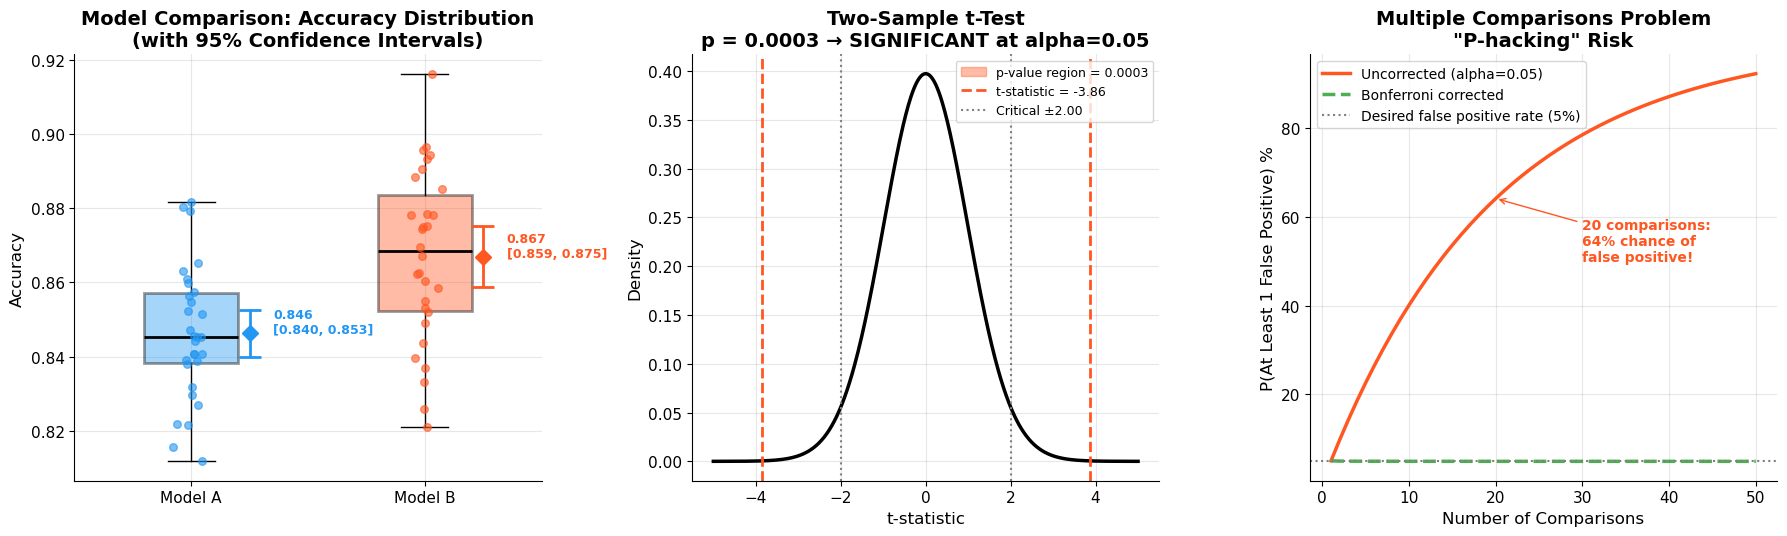

Test Results:
  Independent t-test: t=-3.859, p=0.0003
  Paired t-test:     t=-4.058, p=0.0003
  (Paired test is more powerful when experiments share the same data splits)


In [17]:
# Hypothesis Testing — Comparing Two ML Models
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Scenario: Model A vs Model B accuracy across 30 random seeds
n_seeds = 30
model_a_acc = np.random.normal(0.85, 0.02, n_seeds)  # True mean 0.85
model_b_acc = np.random.normal(0.87, 0.025, n_seeds)  # True mean 0.87 (slightly better)

# --- Left: Distribution of accuracies ---
ax = axes[0]
bp = ax.boxplot([model_a_acc, model_b_acc], labels=['Model A', 'Model B'],
                patch_artist=True, widths=0.4,
                boxprops=dict(linewidth=2),
                medianprops=dict(linewidth=2, color='black'))

bp['boxes'][0].set_facecolor(COLORS[0])
bp['boxes'][0].set_alpha(0.4)
bp['boxes'][1].set_facecolor(COLORS[1])
bp['boxes'][1].set_alpha(0.4)

# Overlay individual points
ax.scatter(np.ones(n_seeds)*1 + np.random.normal(0, 0.03, n_seeds), model_a_acc,
           color=COLORS[0], alpha=0.6, s=30, zorder=5)
ax.scatter(np.ones(n_seeds)*2 + np.random.normal(0, 0.03, n_seeds), model_b_acc,
           color=COLORS[1], alpha=0.6, s=30, zorder=5)

# Confidence intervals
for i, (data, color) in enumerate([(model_a_acc, COLORS[0]), (model_b_acc, COLORS[1])]):
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    ci_low, ci_high = mean - 1.96*se, mean + 1.96*se
    ax.errorbar(i+1+0.25, mean, yerr=1.96*se, fmt='D', color=color, markersize=8,
                capsize=8, capthick=2, linewidth=2)
    ax.text(i+1+0.35, mean, f'{mean:.3f}\n[{ci_low:.3f}, {ci_high:.3f}]',
            fontsize=9, color=color, fontweight='bold')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Accuracy Distribution\n(with 95% Confidence Intervals)', fontweight='bold')

# --- Middle: p-value interpretation ---
ax = axes[1]

# Perform paired t-test
from scipy.stats import ttest_ind, ttest_rel
t_stat, p_value = ttest_ind(model_a_acc, model_b_acc)
t_paired, p_paired = ttest_rel(model_a_acc, model_b_acc)

# Visualize p-value on t-distribution
df = 2*n_seeds - 2
t_range = np.linspace(-5, 5, 500)
t_pdf = stats.t.pdf(t_range, df)

ax.plot(t_range, t_pdf, linewidth=2.5, color='black')
ax.fill_between(t_range, t_pdf, where=(np.abs(t_range) >= np.abs(t_stat)),
                alpha=0.4, color=COLORS[1], label=f'p-value region = {p_value:.4f}')
ax.axvline(t_stat, color=COLORS[1], linewidth=2, linestyle='--',
           label=f't-statistic = {t_stat:.2f}')
ax.axvline(-t_stat, color=COLORS[1], linewidth=2, linestyle='--')

# Critical values
t_crit = stats.t.ppf(0.975, df)
ax.axvline(t_crit, color='gray', linewidth=1.5, linestyle=':', label=f'Critical ±{t_crit:.2f}')
ax.axvline(-t_crit, color='gray', linewidth=1.5, linestyle=':')

ax.set_xlabel('t-statistic')
ax.set_ylabel('Density')
significance = 'SIGNIFICANT' if p_value < 0.05 else 'NOT significant'
ax.set_title(f'Two-Sample t-Test\np = {p_value:.4f} → {significance} at alpha=0.05', fontweight='bold')
ax.legend(fontsize=9)

# --- Right: Multiple comparison problem ---
ax = axes[2]

# Simulate: if we compare many models, false positives accumulate
n_comparisons_list = np.arange(1, 51)
p_any_false_positive = 1 - (1 - 0.05) ** n_comparisons_list

# Bonferroni correction
p_bonferroni = 1 - (1 - 0.05/n_comparisons_list) ** n_comparisons_list

ax.plot(n_comparisons_list, p_any_false_positive * 100, linewidth=2.5, color=COLORS[1],
        label='Uncorrected (alpha=0.05)')
ax.plot(n_comparisons_list, p_bonferroni * 100, linewidth=2.5, color=COLORS[2],
        label='Bonferroni corrected', linestyle='--')
ax.axhline(5, color='gray', linestyle=':', linewidth=1.5, label='Desired false positive rate (5%)')

ax.set_xlabel('Number of Comparisons', fontsize=12)
ax.set_ylabel('P(At Least 1 False Positive) %', fontsize=12)
ax.set_title('Multiple Comparisons Problem\n"P-hacking" Risk', fontweight='bold')
ax.legend(fontsize=10)

# Annotate
ax.annotate(f'20 comparisons:\n{(1-(1-0.05)**20)*100:.0f}% chance of\nfalse positive!',
            xy=(20, (1-(1-0.05)**20)*100), xytext=(30, 50),
            arrowprops=dict(arrowstyle='->', color=COLORS[1]),
            fontsize=10, fontweight='bold', color=COLORS[1])

plt.tight_layout()
plt.show()

print(f'Test Results:')
print(f'  Independent t-test: t={t_stat:.3f}, p={p_value:.4f}')
print(f'  Paired t-test:     t={t_paired:.3f}, p={p_paired:.4f}')
print(f'  (Paired test is more powerful when experiments share the same data splits)')

## 7.2 Bootstrap Confidence Intervals

When you don't want to assume normality, **bootstrap** provides a non-parametric way to estimate confidence intervals:

1. Resample your data **with replacement** $B$ times
2. Compute the statistic of interest on each resample
3. Use the distribution of bootstrap statistics for CI

$$\text{95% CI} = [\hat{\theta}^*_{2.5\%}, \hat{\theta}^*_{97.5\%}]$$

> **ML Usage:** Confidence intervals for accuracy, F1, AUC when test set is small. No distributional assumptions needed!

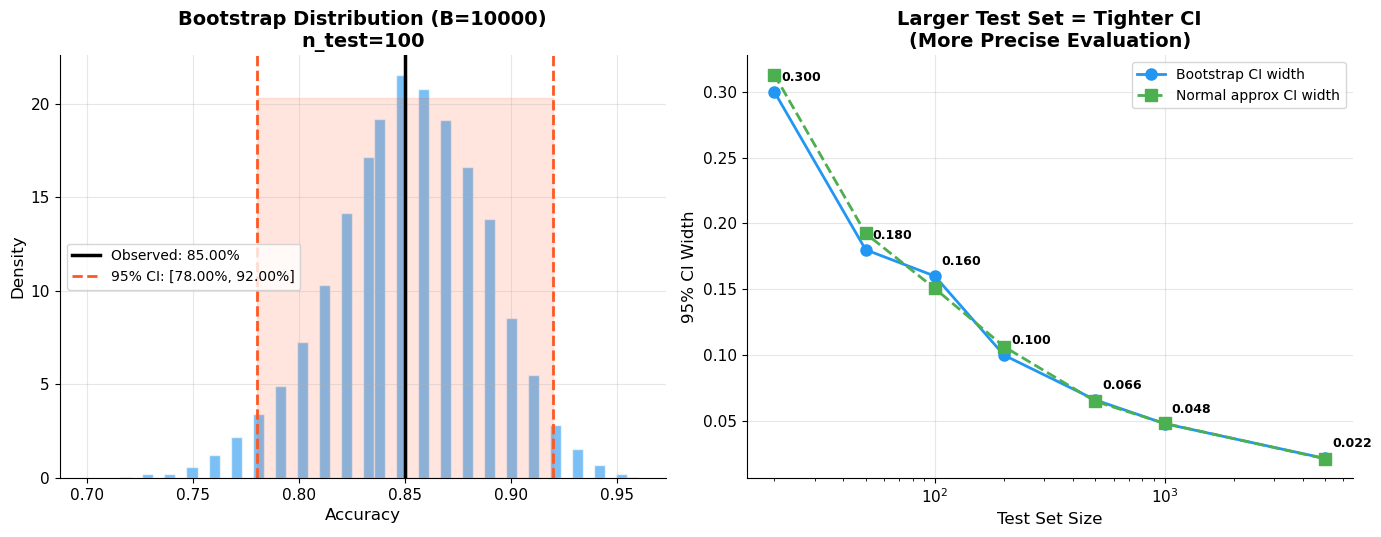

Bootstrap 95% CI: [78.00%, 92.00%]
Normal 95% CI:    [78.00%, 92.00%]

Practical advice: Always report confidence intervals alongside point metrics!


In [18]:
# Bootstrap Confidence Intervals for Model Accuracy
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Simulate: 100 test predictions (binary correct/incorrect)
n_test = 100
predictions = np.random.binomial(1, 0.82, n_test)  # True accuracy ~82%
observed_accuracy = np.mean(predictions)

# Bootstrap
n_bootstrap = 10000
bootstrap_accs = []
for _ in range(n_bootstrap):
    resample = np.random.choice(predictions, size=n_test, replace=True)
    bootstrap_accs.append(np.mean(resample))
bootstrap_accs = np.array(bootstrap_accs)

# Percentile CI
ci_low = np.percentile(bootstrap_accs, 2.5)
ci_high = np.percentile(bootstrap_accs, 97.5)

# Normal approximation CI for comparison
se = np.sqrt(observed_accuracy * (1-observed_accuracy) / n_test)
normal_ci_low = observed_accuracy - 1.96 * se
normal_ci_high = observed_accuracy + 1.96 * se

# --- Left: Bootstrap distribution ---
ax = axes[0]
ax.hist(bootstrap_accs, bins=50, density=True, alpha=0.6, color=COLORS[0], edgecolor='white')
ax.axvline(observed_accuracy, color='black', linewidth=2.5, label=f'Observed: {observed_accuracy:.2%}')
ax.axvline(ci_low, color=COLORS[1], linewidth=2, linestyle='--', label=f'95% CI: [{ci_low:.2%}, {ci_high:.2%}]')
ax.axvline(ci_high, color=COLORS[1], linewidth=2, linestyle='--')
ax.fill_betweenx([0, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 15], ci_low, ci_high,
                 alpha=0.15, color=COLORS[1])

ax.set_xlabel('Accuracy', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Bootstrap Distribution (B={n_bootstrap})\nn_test={n_test}', fontweight='bold')
ax.legend(fontsize=10)

# --- Right: CI width vs test set size ---
ax = axes[1]
test_sizes = [20, 50, 100, 200, 500, 1000, 5000]
ci_widths_boot = []
ci_widths_normal = []

for n in test_sizes:
    preds = np.random.binomial(1, 0.82, n)
    acc = np.mean(preds)
    
    # Bootstrap CI width
    boot = [np.mean(np.random.choice(preds, n, replace=True)) for _ in range(2000)]
    ci_w_boot = np.percentile(boot, 97.5) - np.percentile(boot, 2.5)
    ci_widths_boot.append(ci_w_boot)
    
    # Normal CI width
    se_n = np.sqrt(acc * (1-acc) / n)
    ci_w_normal = 2 * 1.96 * se_n
    ci_widths_normal.append(ci_w_normal)

ax.plot(test_sizes, ci_widths_boot, 'o-', linewidth=2, color=COLORS[0], markersize=8, label='Bootstrap CI width')
ax.plot(test_sizes, ci_widths_normal, 's--', linewidth=2, color=COLORS[2], markersize=8, label='Normal approx CI width')

ax.set_xlabel('Test Set Size', fontsize=12)
ax.set_ylabel('95% CI Width', fontsize=12)
ax.set_title('Larger Test Set = Tighter CI\n(More Precise Evaluation)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xscale('log')

for n, w in zip(test_sizes, ci_widths_boot):
    ax.annotate(f'{w:.3f}', (n, w), textcoords='offset points', xytext=(5, 8),
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Bootstrap 95% CI: [{ci_low:.2%}, {ci_high:.2%}]')
print(f'Normal 95% CI:    [{normal_ci_low:.2%}, {normal_ci_high:.2%}]')
print(f'\nPractical advice: Always report confidence intervals alongside point metrics!')

## 7.3 Practical Guidelines for ML Experiments

| Guideline | Why |
|-----------|-----|
| **Run multiple random seeds** (≥5) | Single-seed results can be misleading |
| **Report mean ± std** | Shows both typical performance and variability |
| **Use paired tests** when possible | More powerful when models share the same data |
| **Correct for multiple comparisons** | Bonferroni, Holm-Bonferroni, or Benjamini-Hochberg |
| **Use bootstrap CIs** for complex metrics | No normality assumptions needed |
| **Check effect size**, not just p-value | A tiny improvement can be "significant" with enough data |
| **Pre-register** hypotheses | Prevents p-hacking and HARKing |

---
# 📋 Part 2 — Summary & Connections

## The Big Picture: How Everything Connects

```
DATA → [Linear Algebra] → Feature transformation (PCA, SVD, embeddings)
  │
  ├── [Probability] → Model outputs as distributions
  │     │
  │     ├── [MLE] → Loss functions (MSE, Cross-Entropy)
  │     │     │
  │     │     └── [MAP] → Regularized loss (L1/L2 = priors on weights)
  │     │
  │     └── [Bayes' Theorem] → Posterior inference
  │           │
  │           ├── [MCMC] → Exact (but slow) sampling
  │           │
  │           └── [Variational Inference] → Approximate (but fast)
  │                 │
  │                 └── [VAE] → ELBO + Reparameterization trick
  │
  └── [Calculus] → Gradients via chain rule
        │
        └── [Optimization] → SGD, Adam → trained model
              │
              └── [Statistics] → Evaluate with CIs and hypothesis tests
```

## Quick Reference

| Concept | Key Formula | ML Connection |
|---------|------------|---------------|
| **SVD** | $A = U\Sigma V^T$ | PCA, LoRA, compression |
| **Gradient** | $\nabla f$ = steepest ascent | Backpropagation |
| **Hessian** | $\nabla^2 f$ = curvature | Loss landscape analysis |
| **Adam** | Adaptive moments + bias correction | Default deep learning optimizer |
| **MLE** | $\arg\max \log P(D|\theta)$ | Derives MSE, Cross-Entropy |
| **MAP** | MLE + $\log P(\theta)$ | MLE + regularization |
| **ELBO** | $E_q[\log P(x|z)] - D_{KL}(q \| p)$ | VAE training objective |
| **Reparam Trick** | $z = \mu + \sigma \cdot \epsilon$ | Backprop through sampling |
| **Bootstrap CI** | Resample B times | Model evaluation |

---

## Potential Part 3 Topics (Advanced)

- 🔥 **Attention & Transformers** — Scaled dot-product attention, multi-head attention, positional encoding math
- 📉 **Bias-Variance Tradeoff** — Decomposition, double descent, generalization theory
- 🎮 **Reinforcement Learning Math** — Bellman equations, policy gradients, PPO
- 🧠 **Information Geometry** — Fisher information matrix, natural gradients
- 📐 **Optimal Transport** — Wasserstein distance, Sinkhorn algorithm
- 🔄 **Diffusion Models** — Score matching, denoising, SDE/ODE formulations

---
*Part 2 of the Math & Statistics for AI/ML series — building deep understanding from the ground up.*